# Set up

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

# Introduction

* Data loading and preprocessing are **critical steps** in any ML project

* Tools like:

  * Pandas → used for loading, exploring data
  * Scikit-Learn → used for preprocessing (transformers)

* These tools are **useful for experimentation and small/medium datasets**

* For **large-scale datasets in TensorFlow**, use:

  * tf.data

* tf.data key capabilities:

  * Efficient data loading and preprocessing
  * Reads multiple files in parallel (**multithreading + queuing**)
  * Supports:

    * Shuffling
    * Batching
  * Performs preprocessing **on-the-fly during training**

* Parallelism advantage:

  * CPU → loads & preprocesses next batch
  * GPU/TPU → trains current batch
  * ⇒ **Maximizes hardware utilization + speeds up training**

* tf.data supports **large datasets (not fitting in memory)**

* Supported data sources:

  * Text files (e.g., CSV)
  * Binary files (fixed-size records)
  * TFRecord format
  * SQL databases
  * External sources via extensions (e.g., BigQuery)

* TFRecord:

  * Efficient binary format
  * Supports **variable-sized records**
  * Often uses **protocol buffers (protobuf)**

* Keras preprocessing:

  * Keras provides **preprocessing layers**
  * These can be embedded directly into the model

* Key benefit of embedding preprocessing:

  * Model can take **raw data directly in production**
  * No need for separate preprocessing code

* Prevents **training/serving skew**:

  * Same preprocessing during:

    * Training
    * Deployment

* Cross-platform advantage:

  * No need to rewrite preprocessing in different languages
  * Reduces inconsistencies

* tf.data + Keras preprocessing can be **used together**:

  * tf.data → efficient data loading
  * Keras layers → convenient preprocessing

* Chapter flow:

  * tf.data API
  * TFRecord format
  * Keras preprocessing layers
  * Integration of both
  * Related tools:

    * TensorFlow Datasets
    * TensorFlow Hub


# The tf.data API

* tf.data.Dataset is the **core concept** of the tf.data API

  * Represents a **sequence (stream) of data items**

* Datasets are typically used to:

  * Load data **gradually from disk**
  * Handle **large-scale data efficiently**

* Creating a dataset:

  * Using `from_tensor_slices()`:

    * Takes a tensor and **splits it along the first dimension**
    * Each slice becomes **one element in the dataset**

* Example concept:

  * If `X = [0,1,2,...,9]` → dataset contains **10 elements (0 to 9)**

* Alternative:

  * `tf.data.Dataset.range(10)`

    * Produces same sequence
    * Difference:

      * `range()` → int64
      * `from_tensor_slices()` → keeps original dtype (e.g., int32)

* Iteration:

  * Dataset is **iterable**
  * Can loop through elements using a `for` loop

* Important property:

  * tf.data is a **streaming API**

    * Efficient for **sequential access**
    * Not designed for:

      * Indexing (`dataset[0]`) ❌
      * Slicing (`dataset[0:5]`) ❌

* Dataset elements can be complex:

  * Not just single tensors
  * Can include:

    * Tuples
    * Dictionaries
    * Nested structures

* Behavior with complex structures:

  * `from_tensor_slices()`:

    * Slices **only tensors**
    * Preserves overall **structure (tuple/dict/nested)**

* Example insight:

  * If input is:

    * Dictionary with lists/tensors
  * Output dataset:

    * Each item is a **dictionary with corresponding sliced values**

* Key takeaway:

  * Dataset = **structured stream of elements**
  * Supports **complex data formats while maintaining structure**
  * Designed for **efficient pipeline processing, not random access**


In [4]:
X = tf.range(10)  # any data tensor
dataset = tf.data.Dataset.from_tensor_slices(X)
dataset

<_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.int32, name=None)>

In [5]:
for item in dataset:
    print(item)

tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(7, shape=(), dtype=int32)
tf.Tensor(8, shape=(), dtype=int32)
tf.Tensor(9, shape=(), dtype=int32)


In [6]:
X_nested = {"a": ([1, 2, 3], [4, 5, 6]), "b": [7, 8, 9]}
dataset = tf.data.Dataset.from_tensor_slices(X_nested)
for item in dataset:
    print(item)

{'a': (<tf.Tensor: shape=(), dtype=int32, numpy=1>, <tf.Tensor: shape=(), dtype=int32, numpy=4>), 'b': <tf.Tensor: shape=(), dtype=int32, numpy=7>}
{'a': (<tf.Tensor: shape=(), dtype=int32, numpy=2>, <tf.Tensor: shape=(), dtype=int32, numpy=5>), 'b': <tf.Tensor: shape=(), dtype=int32, numpy=8>}
{'a': (<tf.Tensor: shape=(), dtype=int32, numpy=3>, <tf.Tensor: shape=(), dtype=int32, numpy=6>), 'b': <tf.Tensor: shape=(), dtype=int32, numpy=9>}


## Chaining Transformations

* Dataset transformations in tf.data.Dataset:

  * Applied using **methods**
  * Each method returns a **new dataset**
  * Supports **method chaining**

* Important principle:

  * Datasets are **immutable**
  * Always reassign:

    * `dataset = dataset.transformation()`

* `repeat(n)`:

  * Repeats dataset **n times**
  * Does **not duplicate data in memory**
  * If no argument → **infinite repetition**

    * Loop must handle stopping condition

* `batch(size)`:

  * Groups elements into **batches of given size**
  * Output becomes **tensor batches instead of single elements**

* Handling last batch:

  * If remaining elements < batch size → smaller batch
  * Use:

    * `drop_remainder=True` → ensures **equal batch sizes**

* Transformation pipeline concept:

  * Example flow:

    * Original dataset → repeat → batch → final dataset
  * Each step builds a **new dataset layer**

* `map(function)`:

  * Applies a function to **each element (or batch)**
  * Used for **data preprocessing**
  * Example:

    * Multiply elements → `x * 2`

* Performance optimization:

  * Use parallel processing in `map()`:

    * `num_parallel_calls = tf.data.AUTOTUNE`
  * Speeds up **heavy preprocessing tasks**

* Requirement for `map()` function:

  * Must be convertible to a **TensorFlow graph (TF function)**

* `filter(function)`:

  * Keeps only elements satisfying a **condition**
  * Example:

    * Keep batches where:

      * sum(x) > 50

* `take(n)`:

  * Retrieves **first n elements**
  * Useful for:

    * Debugging
    * Quick inspection

* Key pipeline idea:

  * tf.data enables **data processing pipeline**

    * repeat → batch → map → filter → take

* Key takeaway:

  * tf.data transformations are:

    * **Lazy (executed during iteration)**
    * **Composable (chainable)**
    * **Efficient (parallel + streaming)**


In [7]:
dataset = tf.data.Dataset.from_tensor_slices(tf.range(10))

In [8]:
dataset

<_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.int32, name=None)>

In [9]:
dataset = dataset.repeat(3).batch(7)

In [10]:
for item in dataset:
    print(item)

tf.Tensor([0 1 2 3 4 5 6], shape=(7,), dtype=int32)
tf.Tensor([7 8 9 0 1 2 3], shape=(7,), dtype=int32)
tf.Tensor([4 5 6 7 8 9 0], shape=(7,), dtype=int32)
tf.Tensor([1 2 3 4 5 6 7], shape=(7,), dtype=int32)
tf.Tensor([8 9], shape=(2,), dtype=int32)


In [11]:
dataset = dataset.map(lambda x: x*2)

In [12]:
for item in dataset:
    print(item)

tf.Tensor([ 0  2  4  6  8 10 12], shape=(7,), dtype=int32)
tf.Tensor([14 16 18  0  2  4  6], shape=(7,), dtype=int32)
tf.Tensor([ 8 10 12 14 16 18  0], shape=(7,), dtype=int32)
tf.Tensor([ 2  4  6  8 10 12 14], shape=(7,), dtype=int32)
tf.Tensor([16 18], shape=(2,), dtype=int32)


In [13]:
dataset = dataset.filter(lambda x: tf.reduce_sum(x)> 50)
for item in dataset:
    print(item)

tf.Tensor([14 16 18  0  2  4  6], shape=(7,), dtype=int32)
tf.Tensor([ 8 10 12 14 16 18  0], shape=(7,), dtype=int32)
tf.Tensor([ 2  4  6  8 10 12 14], shape=(7,), dtype=int32)


In [14]:
dataset.take(2)

<_TakeDataset element_spec=TensorSpec(shape=(None,), dtype=tf.int32, name=None)>

In [15]:
for item in dataset.take(2):
    print(item)

tf.Tensor([14 16 18  0  2  4  6], shape=(7,), dtype=int32)
tf.Tensor([ 8 10 12 14 16 18  0], shape=(7,), dtype=int32)


## Shuffling the Data

* Gradient Descent works best when data is:

  * **IID (Independent and Identically Distributed)**
  * Achieved by **shuffling the dataset**

* `shuffle(buffer_size, seed)` in tf.data.Dataset:

  * Randomizes dataset order using a **buffer-based approach**

* Shuffling mechanism:

  * Fill buffer with initial elements
  * Randomly pick one item from buffer
  * Replace it with a new element from dataset
  * Repeat until dataset is exhausted
  * Finally, randomly empty remaining buffer

* Buffer size importance:

  * Larger buffer → **better randomness (closer to true shuffle)**
  * Small buffer → **poor shuffling (local randomness only)**
  * Constraint:

    * Must fit in **RAM**
    * No need to exceed dataset size

* Randomness control:

  * `seed` → ensures **reproducible shuffling**

* Pipeline example concept:

  * dataset → repeat → shuffle → batch

* Interaction with `repeat()`:

  * Default behavior:

    * Each epoch → **new random order**
  * To fix order:

    * `reshuffle_each_iteration=False`

* Problem with large datasets:

  * Cannot fully shuffle in memory
  * Buffer is **small relative to dataset** → weak randomness

* Solutions for large-scale shuffling:

  * Shuffle data **before loading** (e.g., file-level shuffling)
  * Split dataset into **multiple files**

* Advanced strategy:

  * Read files in **random order**
  * Read multiple files **simultaneously**
  * **Interleave records** from different files
  * Apply additional **shuffle(buffer)** on top

* Benefit of interleaving:

  * Prevents nearby data points (same file) from staying close
  * Improves randomness across dataset

* Key takeaway:

  * Good shuffling = **critical for unbiased training**
  * tf.data provides:

    * Efficient **buffer-based shuffling**
    * Scalable strategies for **very large datasets**


In [16]:
dataset = tf.data.Dataset.from_tensor_slices(tf.range(10)).repeat(2)

In [17]:
dataset = dataset.shuffle(buffer_size=4, seed=42).batch(7)

In [18]:
for item in dataset:
    print(item)

tf.Tensor([1 4 2 3 5 0 6], shape=(7,), dtype=int32)
tf.Tensor([9 8 2 0 3 1 4], shape=(7,), dtype=int32)
tf.Tensor([5 7 9 6 7 8], shape=(6,), dtype=int32)


## Interleaving Lines from Multiple Files

* Real-world pipeline setup:

  * Dataset is:

    * **Shuffled**
    * Split into:

      * Training set
      * Validation set
      * Test set
  * Each split is further divided into **multiple CSV files**

* Each CSV file:

  * Contains:

    * **Input features (8) + target value**
  * First row = **header (must be skipped later)**

* Filepaths handling:

  * Store filepaths in a list or pattern:

    * Example:

      * `"datasets/housing/my_train_*.csv"`

* Creating dataset of filepaths:

  * Using:

    * `tf.data.Dataset.list_files(filepaths, seed)`
  * Behavior:

    * Automatically **shuffles filepaths**
    * Can disable via:

      * `shuffle=False`

* Purpose of shuffling filepaths:

  * Ensures **random file reading order**
  * Improves overall data randomness

* Reading multiple files efficiently:

  * Use `interleave()` method

* `interleave()`:

  * Reads from **multiple files simultaneously**
  * Combines (interleaves) their data streams

* Key parameter:

  * `cycle_length = n_readers`

    * Number of files read in parallel

* Example pipeline:

  * filepath dataset → interleave → line datasets

* Inside `interleave()`:

  * For each filepath:

    * Create:

      * `tf.data.TextLineDataset(filepath)`
    * Then:

      * `.skip(1)` → removes header row

* Internal structure:

  * Multiple datasets exist:

    * Filepath dataset
    * Interleave dataset
    * Multiple TextLineDatasets (one per file)

* How interleaving works:

  * Picks `n_readers` files
  * Reads **one line from each file alternately**
  * Continues until all files are exhausted
  * Then moves to next batch of files

* Important optimization:

  * Works best when:

    * All files have **similar lengths**
  * Otherwise:

    * Later part of longer files → **less interleaved**

* Parallelism:

  * By default:

    * No parallel reading
  * Enable using:

    * `num_parallel_calls`
  * Best practice:

    * `num_parallel_calls = tf.data.AUTOTUNE`

* Output after interleave:

  * Dataset contains:

    * **Raw CSV lines (strings)**

* Alternative approach:

  * `TextLineDataset(filepaths)` directly:

    * Reads files sequentially
    * Can enable parallel reads via:

      * `num_parallel_reads`

* Limitation of alternative:

  * Does NOT:

    * Shuffle files
    * Skip headers automatically

* Key takeaway:

  * Best scalable pipeline:

    * list_files → interleave → skip header
  * Enables:

    * **Efficient multi-file reading**
    * **Better randomness**
    * **Scalable data loading for large datasets**


In [5]:
# extra code – fetches, splits and normalizes the California housing dataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target.reshape(-1, 1), random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [20]:
# extra code – split the dataset into 20 parts and save it to CSV files

import numpy as np
from pathlib import Path

def save_to_csv_files(data, name_prefix, header=None, n_parts=10):
    housing_dir = Path() / "datasets" / "housing"
    housing_dir.mkdir(parents=True, exist_ok=True)
    filename_format = "my_{}_{:02d}.csv"

    filepaths = []
    m = len(data)
    chunks = np.array_split(np.arange(m), n_parts)
    for file_idx, row_indices in enumerate(chunks):
        part_csv = housing_dir / filename_format.format(name_prefix, file_idx)
        filepaths.append(str(part_csv))
        with open(part_csv, "w") as f:
            if header is not None:
                f.write(header)
                f.write("\n")
            for row_idx in row_indices:
                f.write(",".join([str(col) for col in data[row_idx]]))
                f.write("\n")
    return filepaths

train_data = np.c_[X_train, y_train]
valid_data = np.c_[X_valid, y_valid]
test_data = np.c_[X_test, y_test]
header_cols = housing.feature_names + ["MedianHouseValue"]
header = ",".join(header_cols)

train_filepaths = save_to_csv_files(train_data, "train", header, n_parts=20)
valid_filepaths = save_to_csv_files(valid_data, "valid", header, n_parts=10)
test_filepaths = save_to_csv_files(test_data, "test", header, n_parts=10)

In [21]:
print("".join(open(train_filepaths[0]).readlines()[:4]))

MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
3.5214,15.0,3.0499445061043287,1.106548279689234,1447.0,1.6059933407325193,37.63,-122.43,1.442
5.3275,5.0,6.490059642147117,0.9910536779324056,3464.0,3.4433399602385686,33.69,-117.39,1.687
3.1,29.0,7.5423728813559325,1.5915254237288134,1328.0,2.2508474576271187,38.44,-122.98,1.621



In [22]:
train_filepaths

['datasets\\housing\\my_train_00.csv',
 'datasets\\housing\\my_train_01.csv',
 'datasets\\housing\\my_train_02.csv',
 'datasets\\housing\\my_train_03.csv',
 'datasets\\housing\\my_train_04.csv',
 'datasets\\housing\\my_train_05.csv',
 'datasets\\housing\\my_train_06.csv',
 'datasets\\housing\\my_train_07.csv',
 'datasets\\housing\\my_train_08.csv',
 'datasets\\housing\\my_train_09.csv',
 'datasets\\housing\\my_train_10.csv',
 'datasets\\housing\\my_train_11.csv',
 'datasets\\housing\\my_train_12.csv',
 'datasets\\housing\\my_train_13.csv',
 'datasets\\housing\\my_train_14.csv',
 'datasets\\housing\\my_train_15.csv',
 'datasets\\housing\\my_train_16.csv',
 'datasets\\housing\\my_train_17.csv',
 'datasets\\housing\\my_train_18.csv',
 'datasets\\housing\\my_train_19.csv']

In [23]:
filepath_dataset = tf.data.Dataset.list_files(train_filepaths, seed=42)

In [24]:
print(filepath_dataset)

<_ShuffleDataset element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>


In [25]:
# extra code – shows that the file paths are shuffled
for filepath in filepath_dataset:
    print(filepath)

tf.Tensor(b'datasets\\housing\\my_train_05.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_16.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_01.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_17.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_00.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_14.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_10.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_02.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_12.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_19.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_07.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_09.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_13.csv', shape=(), dtype=string)
tf.Tensor(b'datasets\\housing\\my_train_15.csv', sh

In [26]:
n_readers = 5
dataset = filepath_dataset.interleave(
    lambda filepath: tf.data.TextLineDataset(filepath).skip(1),
    cycle_length=n_readers)

In [27]:
for line in dataset.take(5):
    print(line)

tf.Tensor(b'4.5909,16.0,5.475877192982456,1.0964912280701755,1357.0,2.9758771929824563,33.63,-117.71,2.418', shape=(), dtype=string)
tf.Tensor(b'2.4792,24.0,3.4547038327526134,1.1341463414634145,2251.0,3.921602787456446,34.18,-118.38,2.0', shape=(), dtype=string)
tf.Tensor(b'4.2708,45.0,5.121387283236994,0.953757225433526,492.0,2.8439306358381504,37.48,-122.19,2.67', shape=(), dtype=string)
tf.Tensor(b'2.1856,41.0,3.7189873417721517,1.0658227848101265,803.0,2.0329113924050635,32.76,-117.12,1.205', shape=(), dtype=string)
tf.Tensor(b'4.1812,52.0,5.701388888888889,0.9965277777777778,692.0,2.4027777777777777,33.73,-118.31,3.215', shape=(), dtype=string)


## Preprocessing the Data

* Preprocessing goal:

  * Convert **raw CSV byte strings → structured numerical tensors**
  * Perform:

    * Parsing
    * Feature scaling

* Assumptions:

  * Precomputed statistics:

    * `X_mean` → mean of each feature
    * `X_std` → standard deviation of each feature
  * Both are:

    * **1D tensors (size = number of features)**

* Number of inputs:

  * `n_inputs = 8` (number of features)

* `parse_csv_line(line)`:

  * Purpose:

    * Convert **CSV string → tensors**

* Default values (`defs`):

  * Structure:

    * `[0.] * n_inputs` → default = 0 for features
    * `[tf.constant([], dtype=tf.float32)]` → target has **no default**
  * Meaning:

    * Features:

      * Missing values → replaced with 0
    * Target:

      * Missing value → **raises error**

* CSV parsing:

  * Uses:

    * `tf.io.decode_csv(line, record_defaults=defs)`
  * Output:

    * List of **scalar tensors (one per column)**

* Converting to usable format:

  * Use:

    * `tf.stack(fields[:-1])` → features (1D tensor)
    * `tf.stack(fields[-1:])` → target (1D tensor, not scalar)

* Output of `parse_csv_line()`:

  * `(features, target)`
  * Shapes:

    * Features → `(8,)`
    * Target → `(1,)`

* `preprocess(line)`:

  * Calls:

    * `parse_csv_line(line)`
  * Applies **feature scaling (standardization)**:

  [
  X_{scaled} = \frac{X - X_{mean}}{X_{std}}
  ]

* Scaling purpose:

  * Normalize features → improves:

    * Training stability
    * Convergence speed

* Final output of `preprocess()`:

  * Tuple:

    * `(scaled_features, target)`

* Key design decisions:

  * Target kept as **1D tensor (not scalar)** → consistent shape
  * Strict handling of missing target values → avoids silent errors

* Usage in pipeline:

  * Applied using:

    * `dataset.map(preprocess)`

* Key takeaway:

  * Preprocessing step transforms:

    * **Raw string → clean, normalized numerical data**
  * Essential before feeding data into model
  * Fully compatible with **tf.data pipeline (efficient + scalable)**


In [28]:
# extra code – compute the mean and standard deviation of each feature

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [29]:
X_mean, X_std = scaler.mean_, scaler.scale_  # extra code
n_inputs = 8

def parse_csv_line(line):
    defs = [0.] * n_inputs + [tf.constant([], dtype=tf.float32)]
    fields = tf.io.decode_csv(line, record_defaults=defs)
    return tf.stack(fields[:-1]), tf.stack(fields[-1:])

def preprocess(line):
    x, y = parse_csv_line(line)
    return (x - X_mean) / X_std, y

In [30]:
preprocess(b'4.2083,44.0,5.3232,0.9171,846.0,2.3370,37.47,-122.2,2.782')

(<tf.Tensor: shape=(8,), dtype=float32, numpy=
 array([ 0.16579159,  1.216324  , -0.05204564, -0.39215982, -0.5277444 ,
        -0.2633488 ,  0.8543046 , -1.3072058 ], dtype=float32)>,
 <tf.Tensor: shape=(1,), dtype=float32, numpy=array([2.782], dtype=float32)>)

## Putting Everything Together

* Goal:

  * Build a **reusable input pipeline function** for loading + preprocessing + batching data

* Function:

  * `csv_reader_dataset(...)`
  * Returns a fully prepared tf.data.Dataset

* Step-by-step pipeline:

* `list_files(filepaths, seed)`:

  * Creates dataset of filepaths
  * Shuffles file order for randomness

* `interleave(...)`:

  * Reads multiple files in parallel
  * `cycle_length = n_readers` → number of files read simultaneously
  * `num_parallel_calls = n_read_threads` → enables parallel file reading
  * Uses:

    * `TextLineDataset(filepath).skip(1)` → reads lines & skips header

* `map(preprocess, num_parallel_calls=n_parse_threads)`:

  * Applies preprocessing function to each line
  * Converts:

    * Raw CSV → scaled tensors
  * Parallel parsing improves performance

* `shuffle(shuffle_buffer_size, seed)`:

  * Randomizes dataset
  * Large buffer → better randomness

* `batch(batch_size)`:

  * Groups samples into batches
  * Required for efficient training

* `prefetch(1)`:

  * Loads next batch **while current batch is training**
  * Improves pipeline efficiency

* Prefetch concept:

  * Without prefetch:

    * Training waits for data loading ❌
  * With prefetch:

    * CPU → prepares next batch
    * GPU → trains current batch
  * ⇒ **Parallel execution → faster training**

* Parameter flexibility:

  * `n_readers` → number of files read simultaneously
  * `n_read_threads` → parallel file reading threads
  * `n_parse_threads` → parallel preprocessing threads
  * `shuffle_buffer_size` → controls randomness quality
  * `batch_size` → number of samples per batch

* Key pipeline flow:

  * filepaths → interleave → map → shuffle → batch → prefetch

* Key takeaway:

  * This function builds a **production-level data pipeline**
  * Combines:

    * Parallel file reading
    * Parallel preprocessing
    * Efficient shuffling
    * Asynchronous data loading
  * ⇒ Maximizes **CPU + GPU utilization** and training speed 🚀


In [31]:
def csv_reader_dataset(filepaths, n_reader=5, n_read_threads= None, n_parse_threads = 5, 
                       shuffle_buffer_size = 10_000, seed = 42, batch_size = 32):
    dataset = tf.data.Dataset.list_files(filepaths, seed = seed)
    dataset = dataset.interleave( lambda filepath: tf.data.TextLineDataset(filepath).skip(1),
                                  cycle_length=n_readers,num_parallel_calls = n_read_threads)
    dataset = dataset.map(preprocess, num_parallel_calls=n_parse_threads)
    dataset = dataset.shuffle(shuffle_buffer_size, seed= seed)
    return dataset.batch(batch_size).prefetch(1)
    

In [32]:
# extra code – show the first couple of batches produced by the dataset

example_set = csv_reader_dataset(train_filepaths, batch_size=3)
for X_batch, y_batch in example_set.take(2):
    print("X =", X_batch)
    print("y =", y_batch)
    print()

X = tf.Tensor(
[[-1.3957452  -0.04940685 -0.22830808  0.22648273  2.2593622   0.35200632
   0.9667386  -1.4121602 ]
 [ 2.7112627  -1.0778131   0.69413143 -0.14870553  0.51810503  0.3507294
  -0.82285154  0.80680597]
 [-0.13484643 -1.868895    0.01032507 -0.13787179 -0.12893449  0.03143518
   0.2687057   0.13212144]], shape=(3, 8), dtype=float32)
y = tf.Tensor(
[[1.819]
 [3.674]
 [0.954]], shape=(3, 1), dtype=float32)

X = tf.Tensor(
[[ 0.09031774  0.9789995   0.1327582  -0.13753782 -0.23388447  0.10211545
   0.97610843 -1.4121602 ]
 [ 0.05218809 -2.0271113   0.2940109  -0.02403445  0.16218767 -0.02844518
   1.4117942  -0.93737936]
 [-0.672276    0.02970133 -0.76922584 -0.15086786  0.4962024  -0.02741998
  -0.7853724   0.77182245]], shape=(3, 8), dtype=float32)
y = tf.Tensor(
[[2.725]
 [1.205]
 [1.625]], shape=(3, 1), dtype=float32)



In [33]:
# extra code – list all methods of the tf.data.Dataset class
for m in dir(tf.data.Dataset):
    if not (m.startswith("_") or m.endswith("_")):
        func = getattr(tf.data.Dataset, m)
        if hasattr(func, "__doc__"):
            print("● {:21s}{}".format(m + "()", func.__doc__.split("\n")[0]))

● apply()              Applies a transformation function to this dataset.
● as_numpy_iterator()  Returns an iterator which converts all elements of the dataset to numpy.
● batch()              Combines consecutive elements of this dataset into batches.
● bucket_by_sequence_length()A transformation that buckets elements in a `Dataset` by length.
● cache()              Caches the elements in this dataset.
● cardinality()        Returns the cardinality of the dataset, if known.
● choose_from_datasets()Creates a dataset that deterministically chooses elements from `datasets`.
● concatenate()        Creates a `Dataset` by concatenating the given dataset with this dataset.
● counter()            Creates a `Dataset` that counts from `start` in steps of size `step`.
● element_spec()       The type specification of an element of this dataset.
● enumerate()          Enumerates the elements of this dataset.
● filter()             Filters this dataset according to `predicate`.
● fingerprint()     

## Prefetching

* `prefetch(1)` in tf.data.Dataset:

  * Keeps **1 batch ready in advance**
  * While:

    * GPU → training current batch
    * CPU → preparing next batch
  * ⇒ Enables **parallel execution**

* Core idea:

  * Overlap:

    * **Data loading + preprocessing (CPU)**
    * **Model training (GPU)**
  * Eliminates idle time

* Performance impact:

  * Without prefetch:

    * GPU waits for data ❌
  * With prefetch:

    * GPU almost **fully utilized (~100%)** ✅

* Maximum efficiency condition:

  * Data preparation time < training time
  * Achieved by:

    * `num_parallel_calls` in:

      * `interleave()`
      * `map()`
  * Uses **multiple CPU cores**

* Remaining bottleneck:

  * Data transfer:

    * CPU → GPU
  * Depends on:

    * **GPU memory bandwidth**

* Hardware insight:

  * Important GPU factors:

    * Compute power
    * Memory size
    * **Memory bandwidth (data transfer speed)** ⭐

* `cache()` method:

  * Stores dataset in **RAM after first iteration**

* When to use cache:

  * Dataset fits in memory
  * Want faster training across epochs

* Correct placement of `cache()`:

  * After:

    * Loading
    * Preprocessing
  * Before:

    * Shuffling
    * Repeating
    * Batching
    * Prefetching

* Benefit of caching:

  * Each sample:

    * Loaded + preprocessed **only once**
  * Still allows:

    * Different shuffling each epoch
    * Prefetching optimization

* Additional useful dataset methods:

  * `concatenate()` → combine datasets
  * `zip()` → merge multiple datasets
  * `window()` → sliding windows
  * `reduce()` → aggregation
  * `shard()` → split dataset
  * `flat_map()` → flatten mapped datasets
  * `apply()` → custom transformations
  * `unbatch()` → reverse batching
  * `padded_batch()` → batch variable-length data

* Dataset creation methods:

  * `from_generator()` → from Python generator
  * `from_tensors()` → from tensor list

* Extra features:

  * `tf.data.experimental`:

    * Advanced / upcoming features
    * Example:

      * CSV utilities with automatic column type inference

* Key takeaway:

  * Efficient pipeline = combination of:

    * **Parallel loading (interleave + map)**
    * **Shuffling**
    * **Caching (if possible)**
    * **Prefetching**
  * ⇒ Achieves **high-performance training with minimal bottlenecks** 🚀


## Using the Dataset with Keras

* Creating datasets using reusable pipeline:

  * `train_set = csv_reader_dataset(train_filepaths)`
  * `valid_set = csv_reader_dataset(valid_filepaths)`
  * `test_set = csv_reader_dataset(test_filepaths)`

* Behavior:

  * Training set:

    * **Shuffled every epoch**
  * Validation/Test sets:

    * Also shuffled (not necessary, but acceptable)

* Training with Keras:

  * Pass dataset directly to `fit()`:

    * No need for `(X_train, y_train)`

* Example workflow:

  * `model.fit(train_set, validation_data=valid_set, epochs=n)`
  * Keras automatically:

    * Iterates dataset
    * Repeats per epoch
    * Uses new shuffle order each epoch

* Evaluation & Prediction:

  * `model.evaluate(test_set)` → computes metrics
  * `model.predict(dataset)` → generates predictions

* Important note:

  * Prediction dataset:

    * Usually **no labels**
    * If labels exist → **ignored by Keras**

* Flexibility:

  * Can still use:

    * NumPy arrays instead of datasets
  * But must be:

    * Loaded + preprocessed manually

* Custom training loop:

  * Iterate dataset manually:

    * `for X_batch, y_batch in train_set:`
  * Perform:

    * Forward pass
    * Loss computation
    * Backpropagation

* Using TensorFlow optimization:

  * Wrap training step with:

    * `@tf.function`
  * Converts Python → optimized computation graph
  * ⇒ **Faster execution**

* Training step logic:

  * Use:

    * `tf.GradientTape()` → compute gradients
  * Steps:

    * Predict → compute loss
    * Calculate gradients
    * Apply gradients via optimizer

* Loss handling:

  * Total loss:

    * `loss = main_loss + regularization_losses`

* Performance tuning:

  * `steps_per_execution` in `compile()`:

    * Number of batches processed per graph call

* Effect:

  * Larger value (e.g., 50):

    * Fewer graph calls
    * Faster training

* Trade-off:

  * Callbacks (`on_batch_*`) triggered less frequently

* Key insight:

  * tf.data + Keras integration:

    * Seamless pipeline from **data → training → evaluation**

* CSV limitations:

  * Simple and widely used
  * But:

    * Not very efficient
    * Poor support for:

      * Large data
      * Complex data (images, audio)

* When to use TFRecords:

  * If:

    * Data loading/parsing becomes bottleneck

* Key takeaway:

  * You now have:

    * **End-to-end ML pipeline**

      * Data loading
      * Preprocessing
      * Training (high-level & custom)
  * tf.data enables:

    * **Scalable, high-performance training pipelines** 🚀


In [34]:
train_set = csv_reader_dataset(train_filepaths)
valid_set = csv_reader_dataset(valid_filepaths)
test_set = csv_reader_dataset(test_filepaths)

In [35]:
# extra code – for reproducibility
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [36]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=X_train.shape[1:]),
    tf.keras.layers.Dense(1),
])
model.compile(loss="mse", optimizer="sgd")
model.fit(train_set, validation_data=valid_set, epochs=5)

Epoch 1/5


C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    343/Unknown 2s 2ms/step - loss: 1.4444

C:\Users\roush\ml_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.9422 - val_loss: 27.7049
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.5224 - val_loss: 0.8525
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4629 - val_loss: 5.7670
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4352 - val_loss: 0.3917
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4344 - val_loss: 0.7240


In [37]:
test_mse = model.evaluate(test_set)
new_set = test_set.take(3)  # pretend we have 3 new samples
y_pred = model.predict(new_set)  # or you could just pass a NumPy array

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4161
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [38]:
# extra code – defines the optimizer and loss function for training
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
loss_fn = tf.keras.losses.MeanSquaredError()

n_epochs = 5
for epoch in range(n_epochs):
    for X_batch, y_batch in train_set:
        # extra code – perform one Gradient Descent step
        #              as explained in Chapter 12
        print("\rEpoch {}/{}".format(epoch + 1, n_epochs), end="")
        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
            loss = tf.add_n([main_loss] + model.losses)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

Epoch 5/5

In [39]:
@tf.function
def train_one_epoch(model, optimizer, loss_fn, train_set):
    for X_batch, y_batch in train_set:
        with tf.GradientTape() as tape:
            y_pred = model(X_batch)
            main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
            loss = tf.add_n([main_loss] + model.losses)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
loss_fn = tf.keras.losses.MeanSquaredError()
for epoch in range(n_epochs):
    print("\rEpoch {}/{}".format(epoch + 1, n_epochs), end="")
    train_one_epoch(model, optimizer, loss_fn, train_set)

Epoch 5/5

# The TFRecord Format

* TFRecord:

  * Preferred format in TensorFlow for **large-scale data storage**
  * Designed for **efficient reading and training performance**

* Structure of TFRecord:

  * Sequence of **binary records**
  * Each record contains:

    * Length of data
    * CRC checksum (for length validation)
    * Actual data
    * CRC checksum (for data validation)

* Key properties:

  * Supports **variable-sized records**
  * More efficient than text formats (like CSV)
  * Suitable for:

    * Large datasets
    * Complex data (images, audio, etc.)

* Writing TFRecord files:

  * Use:

    * `tf.io.TFRecordWriter`
  * Writes **raw byte strings** (`b"..."`) as records

* Example concept:

  * Each `write()` call → adds **one record** to file

* Reading TFRecord files:

  * Use:

    * `tf.data.TFRecordDataset(filepaths)`

* Output of reading:

  * Each item:

    * **Tensor containing byte string**
    * Needs further parsing for structured data

* Iteration:

  * Dataset can be looped:

    * Returns records sequentially

* Parallel reading:

  * By default:

    * Reads files **one by one**
  * To improve performance:

    * Use:

      * `num_parallel_reads > 1`

* Alternative approach:

  * Combine:

    * `list_files()` + `interleave()`
  * For:

    * More control over parallel reading and shuffling

* Key takeaway:

  * TFRecord = **efficient, scalable binary format**
  * Ideal when:

    * CSV becomes bottleneck
    * Working with **large or complex datasets**
  * Requires:

    * **Custom parsing step after reading**


In [40]:
with tf.io.TFRecordWriter("my_data.tfrecord") as f:
    f.write(b"This is the first record")
    f.write(b"And this is the second record")

In [41]:
filepaths = ["my_data.tfrecord"]
dataset = tf.data.TFRecordDataset(filepaths)
for item in dataset:
    print(item)

tf.Tensor(b'This is the first record', shape=(), dtype=string)
tf.Tensor(b'And this is the second record', shape=(), dtype=string)


In [42]:
# extra code – shows how to read multiple files in parallel and interleave them

filepaths = ["my_test_{}.tfrecord".format(i) for i in range(5)]
for i, filepath in enumerate(filepaths):
    with tf.io.TFRecordWriter(filepath) as f:
        for j in range(3):
            f.write("File {} record {}".format(i, j).encode("utf-8"))

dataset = tf.data.TFRecordDataset(filepaths, num_parallel_reads=3)
for item in dataset:
    print(item)

tf.Tensor(b'File 0 record 0', shape=(), dtype=string)
tf.Tensor(b'File 1 record 0', shape=(), dtype=string)
tf.Tensor(b'File 2 record 0', shape=(), dtype=string)
tf.Tensor(b'File 0 record 1', shape=(), dtype=string)
tf.Tensor(b'File 1 record 1', shape=(), dtype=string)
tf.Tensor(b'File 2 record 1', shape=(), dtype=string)
tf.Tensor(b'File 0 record 2', shape=(), dtype=string)
tf.Tensor(b'File 1 record 2', shape=(), dtype=string)
tf.Tensor(b'File 2 record 2', shape=(), dtype=string)
tf.Tensor(b'File 3 record 0', shape=(), dtype=string)
tf.Tensor(b'File 4 record 0', shape=(), dtype=string)
tf.Tensor(b'File 3 record 1', shape=(), dtype=string)
tf.Tensor(b'File 4 record 1', shape=(), dtype=string)
tf.Tensor(b'File 3 record 2', shape=(), dtype=string)
tf.Tensor(b'File 4 record 2', shape=(), dtype=string)


## Compressed TFRecord Files

* TFRecord files can be **compressed** to:

  * Reduce **file size**
  * Improve **data transfer speed (especially over network)**

* TFRecord supports built-in compression

* Writing compressed TFRecord:

  * Use:

    * `tf.io.TFRecordOptions(compression_type="GZIP")`
  * Pass options to:

    * `TFRecordWriter`

* Compression type:

  * `"GZIP"`:

    * Commonly used
    * Good compression ratio

* Key idea:

  * Data is stored in **compressed binary form**
  * Saves:

    * Disk space
    * Network bandwidth

* Reading compressed TFRecord:

  * Must explicitly specify:

    * `compression_type="GZIP"`

* Important rule:

  * Write and read must use **same compression type**

* Workflow:

  * Write → compress using GZIP
  * Read → decompress automatically during loading

* Trade-off:

  * Pros:

    * Smaller files
    * Faster transfer (network/disk)
  * Cons:

    * Slight **CPU overhead for compression/decompression**

* When to use compression:

  * Large datasets
  * Remote storage (cloud, distributed systems)

* Key takeaway:

  * Compression = **space + transfer optimization**
  * Works seamlessly with tf.data pipelines 🚀


In [43]:
options = tf.io.TFRecordOptions(compression_type="GZIP")
with tf.io.TFRecordWriter("my_compressed.tfrecord", options) as f:
    f.write(b"Compress, compress, compress!")

In [44]:
dataset = tf.data.TFRecordDataset(["my_compressed.tfrecord"],
                                  compression_type="GZIP")

In [45]:
# extra code – shows that the data is decompressed correctly
for item in dataset:
    print(item)

tf.Tensor(b'Compress, compress, compress!', shape=(), dtype=string)


## A Brief Introduction to Protocol Buffers

* TFRecord commonly stores data as:

  * **Serialized Protocol Buffers (protobufs)**

* Protocol Buffers:

  * Developed by Google (2001, open-sourced 2008)
  * Used in:

    * gRPC
    * Distributed systems
  * Features:

    * Portable
    * Efficient
    * Extensible

* Protobuf definition (`.proto` file):

  * Defines **data structure schema**
  * Example structure:

    * Fields:

      * `name → string`
      * `id → int32`
      * `email → repeated string`

* Field identifiers:

  * Numbers like `1, 2, 3`
  * Used in **binary encoding (not field names)**
  * Important for:

    * Compact storage
    * Backward compatibility

* Compilation:

  * `.proto` → compiled using `protoc`
  * Generates **language-specific classes (Python, etc.)**

* In TensorFlow:

  * Most protobuf classes are **already precompiled**
  * No need to manually use `protoc`

* Using protobuf in Python:

  * Create object:

    * `Person(name="Al", id=123, ...)`
  * Access fields:

    * Read/write like attributes
  * Repeated fields:

    * Behave like **lists**

* Serialization:

  * Convert object → binary:

  ```
  serialized = person.SerializeToString()
  ```

* Deserialization:

  * Convert binary → object:

  ```
  person.ParseFromString(serialized)
  ```

* Key concept:

  * Serialization enables:

    * Storage in TFRecord
    * Network transfer

* Limitation in tf.data pipelines:

  * `ParseFromString()`:

    * ❌ Not a TensorFlow operation
    * ❌ Cannot be used directly in pipeline

* Workaround (not ideal):

  * `tf.py_function()`:

    * Slower
    * Less portable

* TensorFlow-native solution:

  * `tf.io.decode_proto()`:

    * Can parse protobufs
    * Requires schema definition

* Best practice:

  * Use **TensorFlow predefined protobuf formats**
  * They have:

    * Optimized parsing ops
    * Better integration with tf.data

* Key takeaway:

  * Protobuf = **structured, efficient binary format inside TFRecords**
  * Enables:

    * Compact storage
    * Fast I/O
  * Prefer:

    * **TensorFlow-native parsing ops** for performance 🚀


For this section you need to [install protobuf](https://developers.google.com/protocol-buffers/docs/downloads). In general you will not have to do so when using TensorFlow, as it comes with functions to create and parse protocol buffers of type `tf.train.Example`, which are generally sufficient. However, in this section we will learn about protocol buffers by creating our own simple protobuf definition, so we need the protobuf compiler (`protoc`): we will use it to compile the protobuf definition to a Python module that we can then use in our code.

In [46]:
%%writefile person.proto
syntax = "proto3";
message Person {
    string name = 1;
    int32 id = 2;
    repeated string email = 3;
}

Writing person.proto


In [47]:
!protoc person.proto --python_out=. --descriptor_set_out=person.desc --include_imports

In [48]:
%ls person*

 Volume in drive C is ACER
 Volume Serial Number is 6042-7170

 Directory of C:\python\machine learning\13_loading_and_preprocessing_data

11-04-2026  16:51                92 person.desc
11-04-2026  16:51               114 person.proto
11-04-2026  16:51             1,297 person_pb2.py
               3 File(s)          1,503 bytes
               0 Dir(s)  295,185,682,432 bytes free


In [ ]:
from person_pb2 import Person  # import the generated access class

person = Person(name="Al", id=123, email=["a@b.com"])  # create a Person
print(person)  # display the Person
# name: "Al"
# id: 123
# email: "a@b.com"
person.name  # read a field
person.name = "Alice"  # modify a field
person.email[0]  # repeated fields can be accessed like arrays
person.email.append("c@d.com")  # add an email address
serialized = person.SerializeToString()  # serialize person to a byte string
serialized
person2 = Person()  # create a new Person
person2.ParseFromString(serialized)  # parse the byte string (27 bytes long)
person == person2  # now they are equal

In rare cases, you may want to parse a custom protobuf (like the one we just created) in TensorFlow. For this you can use the `tf.io.decode_proto()` function:

In [ ]:
# extra code – shows how to use the tf.io.decode_proto() function

person_tf = tf.io.decode_proto(
    bytes=serialized,
    message_type="Person",
    field_names=["name", "id", "email"],
    output_types=[tf.string, tf.int32, tf.string],
    descriptor_source="person.desc")

person_tf.values
# [<tf.Tensor: shape=(1,), dtype=string, numpy=array([b'Alice'], dtype=object)>,
#  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([123], dtype=int32)>,
#  <tf.Tensor: shape=(2,), dtype=string, numpy=array([b'a@b.com', b'c@d.com'], dtype=object)>]

## TensorFlow Protobufs

* TFRecord commonly stores data using:

  * Example protobuf

* Example protobuf:

  * Represents **one data instance (one row/sample)**
  * Contains:

    * **Named features (key-value pairs)**

* Feature types supported:

  * `BytesList` → list of byte strings
  * `FloatList` → list of floats
  * `Int64List` → list of integers

* Structure hierarchy:

  * `Feature`:

    * Holds **one type only** (bytes / float / int)
    * Uses:

      * `oneof` → ensures only one field is active

  * `Features`:

    * Dictionary:
      [
      \text{feature name} \rightarrow \text{Feature object}
      ]

  * `Example`:

    * Contains:

      * One `Features` object

* Optimization:

  * `[packed = true]`:

    * Used for numerical lists
    * Improves **storage efficiency**

* Key design idea:

  * Flexible schema:

    * Each feature is **named**
    * Can store **variable-length data**

* Why `Example` exists:

  * Even though it wraps `Features`:

    * Enables **future extensibility**
    * Maintains **backward compatibility**

* Creating an Example:

  * Use:

    * `tf.train.Feature`
    * `BytesList`, `FloatList`, `Int64List`

* Example structure concept:

  * `"name"` → bytes
  * `"id"` → int64
  * `"emails"` → list of bytes

* Important detail:

  * Strings must be stored as:

    * **byte strings (b"...")**

* Serialization:

  * Convert Example → binary:

  ```
  example.SerializeToString()
  ```

* Writing to TFRecord:

  * Each serialized Example:

    * Stored as **one record**

* Typical workflow:

  * Read raw data (CSV, etc.)
  * Convert each row → Example protobuf
  * Serialize
  * Save to TFRecord files

* Best practice:

  * Create **multiple TFRecord files**
  * Shuffle while writing

* Why multiple files:

  * Enables:

    * Parallel reading
    * Better shuffling

* Pipeline benefit:

  * TFRecord + Example:

    * Efficient storage
    * Fast loading
    * Structured data representation

* Trade-off:

  * More complex than CSV
  * Requires conversion step

* Key takeaway:

  * Example protobuf = **standard format for ML data in TensorFlow**
  * Bridges:

    * Raw data → efficient binary pipeline
  * Essential for **large-scale, production ML systems** 🚀


```proto
syntax = "proto3";

message BytesList { repeated bytes value = 1; }
message FloatList { repeated float value = 1 [packed = true]; }
message Int64List { repeated int64 value = 1 [packed = true]; }
message Feature {
    oneof kind {
        BytesList bytes_list = 1;
        FloatList float_list = 2;
        Int64List int64_list = 3;
    }
};
message Features { map<string, Feature> feature = 1; };
message Example { Features features = 1; };
```

In [52]:
# defnation of tf.Example class above

In [53]:
from tensorflow.train import BytesList, FloatList, Int64List
from tensorflow.train import Feature, Features, Example

person_example = Example(
    features=Features(
        feature={
            "name": Feature(bytes_list=BytesList(value=[b"Alice"])),
            "id": Feature(int64_list=Int64List(value=[123])),
            "emails": Feature(bytes_list=BytesList(value=[b"a@b.com",
                                                          b"c@d.com"]))
        }))

In [54]:
with tf.io.TFRecordWriter("my_contacts.tfrecord") as f:
    for _ in range(5):
        f.write(person_example.SerializeToString())

## Loading and Parsing Examples

* Loading serialized data from TFRecord:

  * Use:

    * `tf.data.TFRecordDataset(filepaths)`

* Parsing records:

  * Use:

    * `tf.io.parse_single_example(serialized_example, feature_description)`

* `feature_description`:

  * Dictionary mapping:
    [
    \text{feature name} \rightarrow \text{feature descriptor}
    ]

* Feature descriptor types:

  * `tf.io.FixedLenFeature(shape, dtype, default_value)`:

    * For **fixed-size features**
    * Output:

      * **Dense tensor**

  * `tf.io.VarLenFeature(dtype)`:

    * For **variable-length features**
    * Output:

      * **Sparse tensor**

* Example mapping:

  * `"name"` → fixed string
  * `"id"` → fixed integer
  * `"emails"` → variable-length string list

* Custom parsing function:

  * Input:

    * Serialized byte string
  * Output:

    * Dictionary of parsed tensors

* Pipeline:

  * TFRecordDataset → `map(parse_function)`

* Output format:

  * Each record becomes:

    * `{feature_name: tensor}`

* Handling sparse tensors:

  * For variable-length features:

    * Output = **SparseTensor**

* Convert sparse → dense:

  ```
  tf.sparse.to_dense(sparse_tensor, default_value)
  ```

* Shortcut:

  * Access actual values directly:

  ```
  sparse_tensor.values
  ```

* Batch parsing (more efficient):

  * Use:

    * `tf.io.parse_example()`

* Difference:

  * `parse_single_example()` → one record
  * `parse_example()` → multiple records (batch)

* Batch pipeline:

  * dataset → batch → map(parse)

* Storing complex data in BytesList:

  * BytesList can hold:

    * Any binary data

* Example uses:

  * Images:

    * Encode:

      * `tf.io.encode_jpeg()`
    * Decode:

      * `tf.io.decode_jpeg()` / `tf.io.decode_image()`

  * Tensors:

    * Serialize:

      * `tf.io.serialize_tensor()`
    * Deserialize:

      * `tf.io.parse_tensor()`

* Key idea:

  * BytesList = **flexible container for arbitrary data**

* Limitation of Example protobuf:

  * Not ideal for:

    * **Nested sequences (lists of lists)**

* Use case example:

  * Text data:

    * Document → sentences → words
    * Comments → words

* Solution:

  * SequenceExample protobuf

* Key takeaway:

  * Parsing TFRecords requires:

    * **Feature schema (feature_description)**
  * Supports:

    * Fixed + variable length data
    * Complex data via encoding
  * Batch parsing improves:

    * **Performance and efficiency** 🚀


In [55]:
feature_description = {
    "name": tf.io.FixedLenFeature([], tf.string, default_value=""),
    "id": tf.io.FixedLenFeature([], tf.int64, default_value=0),
    "emails": tf.io.VarLenFeature(tf.string),
}

def parse(serialized_example):
    return tf.io.parse_single_example(serialized_example, feature_description)

dataset = tf.data.TFRecordDataset(["my_contacts.tfrecord"]).map(parse)
for parsed_example in dataset:
    print(parsed_example)

{'emails': SparseTensor(indices=tf.Tensor(
[[0]
 [1]], shape=(2, 1), dtype=int64), values=tf.Tensor([b'a@b.com' b'c@d.com'], shape=(2,), dtype=string), dense_shape=tf.Tensor([2], shape=(1,), dtype=int64)), 'id': <tf.Tensor: shape=(), dtype=int64, numpy=123>, 'name': <tf.Tensor: shape=(), dtype=string, numpy=b'Alice'>}
{'emails': SparseTensor(indices=tf.Tensor(
[[0]
 [1]], shape=(2, 1), dtype=int64), values=tf.Tensor([b'a@b.com' b'c@d.com'], shape=(2,), dtype=string), dense_shape=tf.Tensor([2], shape=(1,), dtype=int64)), 'id': <tf.Tensor: shape=(), dtype=int64, numpy=123>, 'name': <tf.Tensor: shape=(), dtype=string, numpy=b'Alice'>}
{'emails': SparseTensor(indices=tf.Tensor(
[[0]
 [1]], shape=(2, 1), dtype=int64), values=tf.Tensor([b'a@b.com' b'c@d.com'], shape=(2,), dtype=string), dense_shape=tf.Tensor([2], shape=(1,), dtype=int64)), 'id': <tf.Tensor: shape=(), dtype=int64, numpy=123>, 'name': <tf.Tensor: shape=(), dtype=string, numpy=b'Alice'>}
{'emails': SparseTensor(indices=tf.Tenso

In [56]:
tf.sparse.to_dense(parsed_example["emails"], default_value=b"")

<tf.Tensor: shape=(2,), dtype=string, numpy=array([b'a@b.com', b'c@d.com'], dtype=object)>

In [57]:
parsed_example["emails"].values

<tf.Tensor: shape=(2,), dtype=string, numpy=array([b'a@b.com', b'c@d.com'], dtype=object)>

In [58]:
def parse(serialized_examples):
    return tf.io.parse_example(serialized_examples, feature_description)

dataset = tf.data.TFRecordDataset(["my_contacts.tfrecord"]).batch(2).map(parse)
for parsed_examples in dataset:
    print(parsed_examples)  # two examples at a time

{'emails': SparseTensor(indices=tf.Tensor(
[[0 0]
 [0 1]
 [1 0]
 [1 1]], shape=(4, 2), dtype=int64), values=tf.Tensor([b'a@b.com' b'c@d.com' b'a@b.com' b'c@d.com'], shape=(4,), dtype=string), dense_shape=tf.Tensor([2 2], shape=(2,), dtype=int64)), 'id': <tf.Tensor: shape=(2,), dtype=int64, numpy=array([123, 123])>, 'name': <tf.Tensor: shape=(2,), dtype=string, numpy=array([b'Alice', b'Alice'], dtype=object)>}
{'emails': SparseTensor(indices=tf.Tensor(
[[0 0]
 [0 1]
 [1 0]
 [1 1]], shape=(4, 2), dtype=int64), values=tf.Tensor([b'a@b.com' b'c@d.com' b'a@b.com' b'c@d.com'], shape=(4,), dtype=string), dense_shape=tf.Tensor([2 2], shape=(2,), dtype=int64)), 'id': <tf.Tensor: shape=(2,), dtype=int64, numpy=array([123, 123])>, 'name': <tf.Tensor: shape=(2,), dtype=string, numpy=array([b'Alice', b'Alice'], dtype=object)>}
{'emails': SparseTensor(indices=tf.Tensor(
[[0 0]
 [0 1]], shape=(2, 2), dtype=int64), values=tf.Tensor([b'a@b.com' b'c@d.com'], shape=(2,), dtype=string), dense_shape=tf.Ten

In [59]:
parsed_examples

{'emails': SparseTensor(indices=tf.Tensor(
 [[0 0]
  [0 1]], shape=(2, 2), dtype=int64), values=tf.Tensor([b'a@b.com' b'c@d.com'], shape=(2,), dtype=string), dense_shape=tf.Tensor([1 2], shape=(2,), dtype=int64)),
 'id': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([123])>,
 'name': <tf.Tensor: shape=(1,), dtype=string, numpy=array([b'Alice'], dtype=object)>}

## Handling Lists of Lists Using the SequenceExample Protobuf

* SequenceExample protobuf:

  * Designed for **sequential / structured data**
  * Extends Example protobuf to handle **nested sequences**

* Structure of SequenceExample:

  * `Features (context)`:

    * Stores **global/static data**
    * Example:

      * document title
      * author
      * metadata

  * `FeatureLists (sequence data)`:

    * Dictionary:
      [
      \text{name} \rightarrow \text{FeatureList}
      ]

  * `FeatureList`:

    * Contains **list of Feature objects**

  * Each `Feature`:

    * Can store:

      * BytesList
      * FloatList
      * Int64List

* Conceptual hierarchy:

  * Context → single data
  * FeatureLists → sequences of sequences

* Example use case:

  * Document classification:

    * Context:

      * author, title
    * FeatureLists:

      * `"content"` → list of sentences
      * `"comments"` → list of comments
    * Each sentence/comment:

      * list of word IDs

* Parsing SequenceExample:

  * Single record:

    * `tf.io.parse_single_sequence_example()`

  * Batch parsing:

    * `tf.io.parse_sequence_example()`

* Output of parsing:

  * Tuple:

    * `(context_features, sequence_features)`
  * Both are:

    * Dictionaries

* Handling variable-length sequences:

  * Output often:

    * **Sparse tensors**

* Convert to better structure:

  * Use:

    * `tf.RaggedTensor.from_sparse()`

* Ragged Tensor:

  * Supports:

    * **variable-length sequences naturally**
  * Better than padding in many cases

* Example transformation:

  * Sparse → Ragged → usable sequence data

* Key difference vs Example:

  * Example:

    * Flat structure
  * SequenceExample:

    * Nested sequence structure

* When to use SequenceExample:

  * Data with:

    * Sequences of sequences
    * Time series
    * NLP (documents → sentences → words)

* Pipeline compatibility:

  * Works with:

    * tf.data.Dataset
  * Integrated parsing in pipeline

* Key takeaway:

  * SequenceExample = **advanced structured format for sequential data**
  * Enables:

    * Efficient storage
    * Flexible parsing
    * Handling of variable-length sequences
  * Critical for:

    * **NLP, time-series, and hierarchical data pipelines** 🚀


```proto
syntax = "proto3";

message FeatureList { repeated Feature feature = 1; };
message FeatureLists { map<string, FeatureList> feature_list = 1; };
message SequenceExample {
    Features context = 1;
    FeatureLists feature_lists = 2;
};
```

In [60]:
from tensorflow.train import FeatureList, FeatureLists, SequenceExample

context = Features(feature={
    "author_id": Feature(int64_list=Int64List(value=[123])),
    "title": Feature(bytes_list=BytesList(value=[b"A", b"desert", b"place", b"."])),
    "pub_date": Feature(int64_list=Int64List(value=[1623, 12, 25]))
})

content = [["When", "shall", "we", "three", "meet", "again", "?"],
           ["In", "thunder", ",", "lightning", ",", "or", "in", "rain", "?"]]
comments = [["When", "the", "hurlyburly", "'s", "done", "."],
            ["When", "the", "battle", "'s", "lost", "and", "won", "."]]

def words_to_feature(words):
    return Feature(bytes_list=BytesList(value=[word.encode("utf-8")
                                               for word in words]))

content_features = [words_to_feature(sentence) for sentence in content]
comments_features = [words_to_feature(comment) for comment in comments]
            
sequence_example = SequenceExample(
    context=context,
    feature_lists=FeatureLists(feature_list={
        "content": FeatureList(feature=content_features),
        "comments": FeatureList(feature=comments_features)
    }))

In [61]:
sequence_example

context {
  feature {
    key: "title"
    value {
      bytes_list {
        value: "A"
        value: "desert"
        value: "place"
        value: "."
      }
    }
  }
  feature {
    key: "pub_date"
    value {
      int64_list {
        value: 1623
        value: 12
        value: 25
      }
    }
  }
  feature {
    key: "author_id"
    value {
      int64_list {
        value: 123
      }
    }
  }
}
feature_lists {
  feature_list {
    key: "content"
    value {
      feature {
        bytes_list {
          value: "When"
          value: "shall"
          value: "we"
          value: "three"
          value: "meet"
          value: "again"
          value: "?"
        }
      }
      feature {
        bytes_list {
          value: "In"
          value: "thunder"
          value: ","
          value: "lightning"
          value: ","
          value: "or"
          value: "in"
          value: "rain"
          value: "?"
        }
      }
    }
  }
  feature_list {
    key: "c

In [62]:
serialized_sequence_example = sequence_example.SerializeToString()

In [63]:
context_feature_descriptions = {
    "author_id": tf.io.FixedLenFeature([], tf.int64, default_value=0),
    "title": tf.io.VarLenFeature(tf.string),
    "pub_date": tf.io.FixedLenFeature([3], tf.int64, default_value=[0, 0, 0]),
}
sequence_feature_descriptions = {
    "content": tf.io.VarLenFeature(tf.string),
    "comments": tf.io.VarLenFeature(tf.string),
}

In [64]:
parsed_context, parsed_feature_lists = tf.io.parse_single_sequence_example(
    serialized_sequence_example, context_feature_descriptions,
    sequence_feature_descriptions)
parsed_content = tf.RaggedTensor.from_sparse(parsed_feature_lists["content"])

In [65]:
parsed_context

{'title': SparseTensor(indices=tf.Tensor(
 [[0]
  [1]
  [2]
  [3]], shape=(4, 1), dtype=int64), values=tf.Tensor([b'A' b'desert' b'place' b'.'], shape=(4,), dtype=string), dense_shape=tf.Tensor([4], shape=(1,), dtype=int64)),
 'author_id': <tf.Tensor: shape=(), dtype=int64, numpy=123>,
 'pub_date': <tf.Tensor: shape=(3,), dtype=int64, numpy=array([1623,   12,   25])>}

In [66]:
parsed_context["title"].values

<tf.Tensor: shape=(4,), dtype=string, numpy=array([b'A', b'desert', b'place', b'.'], dtype=object)>

In [67]:
parsed_feature_lists

{'comments': SparseTensor(indices=tf.Tensor(
 [[0 0]
  [0 1]
  [0 2]
  [0 3]
  [0 4]
  [0 5]
  [1 0]
  [1 1]
  [1 2]
  [1 3]
  [1 4]
  [1 5]
  [1 6]
  [1 7]], shape=(14, 2), dtype=int64), values=tf.Tensor(
 [b'When' b'the' b'hurlyburly' b"'s" b'done' b'.' b'When' b'the' b'battle'
  b"'s" b'lost' b'and' b'won' b'.'], shape=(14,), dtype=string), dense_shape=tf.Tensor([2 8], shape=(2,), dtype=int64)),
 'content': SparseTensor(indices=tf.Tensor(
 [[0 0]
  [0 1]
  [0 2]
  [0 3]
  [0 4]
  [0 5]
  [0 6]
  [1 0]
  [1 1]
  [1 2]
  [1 3]
  [1 4]
  [1 5]
  [1 6]
  [1 7]
  [1 8]], shape=(16, 2), dtype=int64), values=tf.Tensor(
 [b'When' b'shall' b'we' b'three' b'meet' b'again' b'?' b'In' b'thunder'
  b',' b'lightning' b',' b'or' b'in' b'rain' b'?'], shape=(16,), dtype=string), dense_shape=tf.Tensor([2 9], shape=(2,), dtype=int64))}

In [68]:
print(tf.RaggedTensor.from_sparse(parsed_feature_lists["content"]))

<tf.RaggedTensor [[b'When', b'shall', b'we', b'three', b'meet', b'again', b'?'],
 [b'In', b'thunder', b',', b'lightning', b',', b'or', b'in', b'rain', b'?']]>


## Extra Material – Storing Images and Tensors in TFRecords

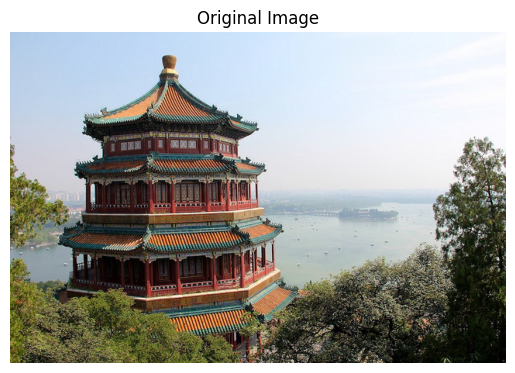

In [69]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_images

img = load_sample_images()["images"][0]
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [70]:
# Now let's create an Example protobuf containing the image encoded as JPEG:
data = tf.io.encode_jpeg(img)
example_with_image = Example(features=Features(feature={
    "image": Feature(bytes_list=BytesList(value=[data.numpy()]))}))
serialized_example = example_with_image.SerializeToString()
with tf.io.TFRecordWriter("my_image.tfrecord") as f:
    f.write(serialized_example)

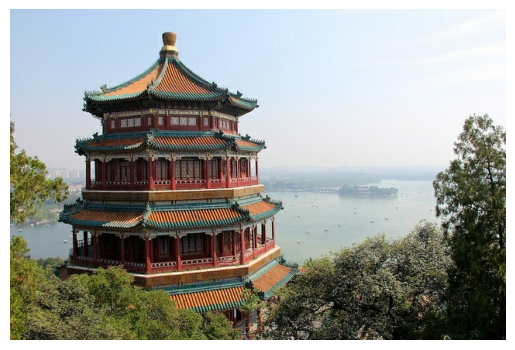

In [71]:
feature_description = { "image": tf.io.VarLenFeature(tf.string) }

def parse(serialized_example):
    example_with_image = tf.io.parse_single_example(serialized_example,
                                                    feature_description)
    return tf.io.decode_jpeg(example_with_image["image"].values[0])
    # or you can use tf.io.decode_image() instead

dataset = tf.data.TFRecordDataset("my_image.tfrecord").map(parse)
for image in dataset:
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [72]:
tensor = tf.constant([[0., 1.], [2., 3.], [4., 5.]])
serialized = tf.io.serialize_tensor(tensor)
serialized

<tf.Tensor: shape=(), dtype=string, numpy=b'\x08\x01\x12\x08\x12\x02\x08\x03\x12\x02\x08\x02"\x18\x00\x00\x00\x00\x00\x00\x80?\x00\x00\x00@\x00\x00@@\x00\x00\x80@\x00\x00\xa0@'>

In [73]:
tf.io.parse_tensor(serialized, out_type=tf.float32)

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[0., 1.],
       [2., 3.],
       [4., 5.]], dtype=float32)>

In [74]:
sparse_tensor = parsed_example["emails"]
serialized_sparse = tf.io.serialize_sparse(sparse_tensor)
serialized_sparse

<tf.Tensor: shape=(3,), dtype=string, numpy=
array([b'\x08\t\x12\x08\x12\x02\x08\x02\x12\x02\x08\x01"\x10\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00',
       b'\x08\x07\x12\x04\x12\x02\x08\x02"\x10\x07\x07a@b.comc@d.com',
       b'\x08\t\x12\x04\x12\x02\x08\x01"\x08\x02\x00\x00\x00\x00\x00\x00\x00'],
      dtype=object)>

In [75]:
BytesList(value=serialized_sparse.numpy())

value: "\010\t\022\010\022\002\010\002\022\002\010\001\"\020\000\000\000\000\000\000\000\000\001\000\000\000\000\000\000\000"
value: "\010\007\022\004\022\002\010\002\"\020\007\007a@b.comc@d.com"
value: "\010\t\022\004\022\002\010\001\"\010\002\000\000\000\000\000\000\000"

# Keras Preprocessing Layers

* Data preprocessing is essential for neural networks:

  * Normalize numerical features
  * Encode categorical features
  * Process text
  * Resize/crop images

* Three main preprocessing approaches:

* **1. Preprocess before training (offline)**:

  * Tools:

    * NumPy
    * Pandas
    * Scikit-Learn
  * Done while preparing dataset files
  * Requirement:

    * Must apply **same preprocessing in production**

* **2. Preprocess using tf.data (on-the-fly)**:

  * Use:

    * `dataset.map(preprocessing_function)`
  * Happens during data loading
  * Still requires:

    * Same preprocessing logic in production

* **3. Preprocessing inside the model (best approach)**:

  * Use:

    * Keras preprocessing layers
  * Preprocessing becomes part of the model

* Advantages of in-model preprocessing:

  * Model accepts **raw input directly**
  * No need to rewrite preprocessing code in production
  * Eliminates:

    * **training/serving mismatch (skew)**
  * Easier deployment across:

    * Different platforms/languages

* Keras preprocessing layers support:

  * Numerical features
  * Categorical features
  * Text data
  * Images

* Pipeline simplification:

  * Raw data → model (with preprocessing layers) → output

* Key takeaway:

  * Best practice:

    * **Embed preprocessing inside the model**
  * Ensures:

    * Consistency
    * Simplicity
    * Production reliability 🚀


## The Normalization Layer

* Keras provides:

  * `Normalization` layer for **feature standardization**

* Purpose of Normalization:

  * Scale features using:
    $$[
    X_{scaled} = \frac{X - \mu}{\sigma}
    ]$$

* Ways to use Normalization layer:

* **1. Inside the model (end-to-end approach)**:

  * Add as first layer in model
  * Use:

    * `adapt(X_train)` to compute:

      * Mean (μ)
      * Variance (σ²)

* `adapt()`:

  * Learns statistics from data
  * Does NOT require full dataset:

    * Small representative sample is enough

* Advantage:

  * Model handles preprocessing automatically
  * Eliminates:

    * **training/serving skew (mismatch)**

* Risk avoided:

  * Separate preprocessing code → inconsistency → degraded performance

* Drawback:

  * Slightly slower training:

    * Preprocessing happens **every epoch**

* **2. Standalone preprocessing (faster training)**:

  * Use layer outside model:

    * Fit (`adapt`) once
    * Transform dataset once

* Workflow:

  * `X_train_scaled = norm_layer(X_train)`
  * Train model on scaled data

* Advantage:

  * Faster training:

    * No repeated preprocessing per epoch

* Drawback:

  * Model cannot preprocess new data automatically

* **3. Best practice (combined approach)**:

  * Step 1:

    * Preprocess once for training (fast)
  * Step 2:

    * Wrap trained model with normalization layer

* Final model:

  * `final_model = Sequential([norm_layer, trained_model])`

* Result:

  * Fast training + production-safe model

* Prediction:

  * Raw input → normalized → prediction

* Integration with tf.data.Dataset:

  * `adapt()` can take dataset as input
  * Apply normalization via:

    * `dataset.map(lambda X, y: (norm_layer(X), y))`

* Custom preprocessing layer:

  * Can create custom layer by subclassing:

    * `tf.keras.layers.Layer`

* Custom normalization logic:

  * Compute:

    * Mean
    * Standard deviation

* Numerical stability:

  * Add small epsilon:
    $$[
    X_{scaled} = \frac{X - \mu}{\sigma + \epsilon}
    ]$$

* Key takeaway:

  * Normalization is **critical for neural network performance**
  * Best strategy:

    * **Preprocess once for speed + include layer for deployment**
  * Ensures:

    * Efficiency
    * Consistency
    * Robust production pipeline 🚀


In [6]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
norm_layer = tf.keras.layers.Normalization()
model = tf.keras.models.Sequential([
    norm_layer,
    tf.keras.layers.Dense(1)
])
model.compile(loss="mse", optimizer=tf.keras.optimizers.SGD(learning_rate=2e-3))
norm_layer.adapt(X_train)  # computes the mean and variance of every feature
model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=5)

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.9270 - val_loss: 1.1204
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7722 - val_loss: 0.8824
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6582 - val_loss: 0.7399
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6286 - val_loss: 0.7216
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6091 - val_loss: 0.6964


In [7]:
norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(X_train)
X_train_scaled = norm_layer(X_train)
X_valid_scaled = norm_layer(X_valid)

In [8]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1)])
model.compile(loss="mse", optimizer=tf.keras.optimizers.SGD(learning_rate=2e-3))
model.fit(X_train_scaled, y_train, epochs=5,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.0467 - val_loss: 0.8768
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6806 - val_loss: 0.6930
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5674 - val_loss: 0.6250
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5567 - val_loss: 0.6215
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5525 - val_loss: 0.6146


In [9]:
final_model = tf.keras.Sequential([norm_layer, model])
X_new = X_test[:3]  # pretend we have a few new instances (unscaled)
y_pred = final_model(X_new)  # preprocesses the data and makes predictions

In [10]:
y_pred

<tf.Tensor: shape=(3, 1), dtype=float32, numpy=
array([[0.84575295],
       [1.6819772 ],
       [2.6851654 ]], dtype=float32)>

In [11]:
# extra code – creates a dataset to demo applying the norm_layer using map()
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(5)

In [12]:
dataset = dataset.map(lambda X, y: (norm_layer(X), y))

In [13]:
list(dataset.take(1))  # extra code – shows the first batch

[(<tf.Tensor: shape=(5, 8), dtype=float32, numpy=
  array([[-0.19397889, -1.0778131 , -0.9433854 ,  0.01485314,  0.02073333,
          -0.57291627,  0.9292612 , -1.4221537 ],
         [ 0.7519831 , -1.868895  ,  0.40547806, -0.23327684,  1.8614649 ,
           0.20516537, -0.9165477 ,  1.0966716 ],
         [-0.41469118,  0.02970133,  0.8180882 ,  1.0567837 , -0.0878671 ,
          -0.2998328 ,  1.3087282 , -1.697027  ],
         [ 1.7188957 , -1.3151377 ,  0.32664376, -0.2195511 , -0.33792186,
          -0.11146631, -0.9821345 ,  0.94174504],
         [-0.9620722 , -1.2360295 , -0.05625783, -0.03124396,  1.7090592 ,
          -0.30256987, -0.80411196,  1.3265638 ]], dtype=float32)>,
  <tf.Tensor: shape=(5, 1), dtype=float64, numpy=
  array([[1.442],
         [1.687],
         [1.621],
         [2.621],
         [0.956]])>)]

In [14]:
class MyNormalization(tf.keras.layers.Layer):
    def adapt(self, X):
        self.mean_ = np.mean(X, axis=0, keepdims=True)
        self.std_ = np.std(X, axis=0, keepdims=True)

    def call(self, inputs):
        eps = tf.keras.backend.epsilon()  # a small smoothing term
        return (inputs - self.mean_) / (self.std_ + eps)

In [16]:
import numpy as np

my_norm_layer = MyNormalization()
my_norm_layer.adapt(X_train)
X_train_scaled = my_norm_layer(X_train)

## The Discretization Layer

* Keras provides:

  * `Discretization` layer for **converting numerical → categorical features**

* Purpose of Discretization:

  * Map continuous values into **bins (ranges)**
  * Output:

    * **Integer category indices**

* Use cases:

  * Features with:

    * **Multimodal distributions**
    * **Non-linear relationships with target**

* Concept:

  * Divide value range into bins:
    $[
    x \rightarrow \text{bin index}
    ]$

* Example behavior:

  * Input ages:

    * `[10, 93, 57, 18, 37, 5]`
  * Bin boundaries:

    * `[18, 50]`
  * Categories:

    * `< 18 → 0`
    * `18–50 → 1`
    * `≥ 50 → 2`

* Output:

  * Each value mapped to **bin index**

* Two ways to define bins:

* **1. Manual bin boundaries**:

  * Specify:

    * `bin_boundaries=[...]`
  * Full control over ranges

* **2. Automatic binning**:

  * Specify:

    * `num_bins = k`
  * Use:

    * `adapt(data)`

* Automatic binning logic:

  * Uses **percentiles**
  * Example:

    * `num_bins=3` → splits at:

      * ~33rd percentile
      * ~66th percentile

* Advantage of automatic binning:

  * Adapts to **data distribution**

* Important warning:

  * Output categories are:

    * **integers (0,1,2,...)**
  * These are:

    * **not ordinal values** ❌
    * Just labels

* Problem:

  * Neural networks may assume:
    $[
    2 > 1 > 0
    ]$
  * Which is **incorrect interpretation**

* Solution:

  * Use **encoding (e.g., one-hot encoding)**

* Key takeaway:

  * Discretization:

    * Converts numerical → categorical
    * Helps model capture **non-linear patterns**
  * Must be followed by:

    * **Proper encoding (like one-hot)** for neural networks 🚀


In [17]:
age = tf.constant([[10.], [93.], [57.], [18.], [37.], [5.]])
discretize_layer = tf.keras.layers.Discretization(bin_boundaries=[18., 50.])
age_categories = discretize_layer(age)
age_categories

<tf.Tensor: shape=(6, 1), dtype=int32, numpy=
array([[0],
       [2],
       [2],
       [1],
       [1],
       [0]], dtype=int32)>

In [18]:
discretize_layer = tf.keras.layers.Discretization(num_bins=3)
discretize_layer.adapt(age)
age_categories = discretize_layer(age)
age_categories

<tf.Tensor: shape=(6, 1), dtype=int32, numpy=
array([[1],
       [2],
       [2],
       [1],
       [2],
       [0]], dtype=int32)>

## The CategoryEncoding Layer

* When categorical features have **few categories (≈ < 10–20)**:

  * **One-hot encoding** is a good choice

* Keras provides:

  * `CategoryEncoding` layer for encoding categorical data

* One-hot encoding:

  * Converts category index → binary vector
  * Example:
    $$[
    1 \rightarrow [0,1,0], \quad 2 \rightarrow [0,0,1]
    ]$$

* Usage:

  * `CategoryEncoding(num_tokens = total_categories)`

* Output:

  * Shape:

    * `(samples, num_tokens)`
  * Each row:

    * One active position = 1

* Multi-feature input behavior:

  * If multiple categorical values per sample:

    * Default → **multi-hot encoding**

* Multi-hot encoding:

  * Marks all present categories as 1
  * Ignores:

    * Order
    * Source feature

* Example:
  $$[
  [1,0] \rightarrow [1,1,0]
  ]$$

* Count encoding:

  * Use:

    * `output_mode="count"`
  * Output:

    * Number of occurrences of each category

* Example:
  $$[
  [2,2] \rightarrow [0,0,2]
  ]$$

* Information loss issue:

  * Multi-hot / count encoding:

    * Lose feature origin information
  * Example:
    $$[
    [0,1] \text{ and } [1,0] \rightarrow \text{same encoding}
    ]$$

* Solution:

  * Encode each feature **separately**

* Per-feature one-hot encoding:

  * Concatenate outputs
  * Preserves:

    * Feature identity

* Example:
  $$[
  [0,1] \rightarrow [1,0,0,0,1,0]
  ]$$

* Alternative trick:

  * Offset category indices:
    $$[
    \text{feature2} = \text{feature2} + k
    ]$$
  * Ensures:

    * No overlap between features

* Trade-off:

  * Pros:

    * Preserves full information
  * Cons:

    * Increases:

      * Feature size
      * Model parameters

* Model design decision:

  * Choose between:

    * Multi-hot (compact, less info)
    * Per-feature one-hot (larger, more info)

* No fixed rule:

  * Must:

    * Experiment and validate

* Key takeaway:

  * CategoryEncoding enables:

    * One-hot
    * Multi-hot
    * Count encoding
  * Important to:

    * Balance **information retention vs model complexity** 🚀

* Next step:

  * For **text categorical data**:

    * Use:

      * `StringLookup` layer


In [19]:
onehot_layer = tf.keras.layers.CategoryEncoding(num_tokens=3)
onehot_layer(age_categories)

<tf.Tensor: shape=(6, 3), dtype=float32, numpy=
array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]], dtype=float32)>

In [20]:
two_age_categories = np.array([[1, 0], [2, 2], [2, 0]])
onehot_layer(two_age_categories)

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 0.],
       [0., 0., 1.],
       [1., 0., 1.]], dtype=float32)>

In [21]:
onehot_layer = tf.keras.layers.CategoryEncoding(num_tokens=3, output_mode="count")
onehot_layer(two_age_categories)

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 0.],
       [0., 0., 2.],
       [1., 0., 1.]], dtype=float32)>

In [22]:
onehot_layer = tf.keras.layers.CategoryEncoding(num_tokens=3 + 3)
onehot_layer(two_age_categories + [0, 3])  # adds 3 to the second feature

<tf.Tensor: shape=(3, 6), dtype=float32, numpy=
array([[0., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 1.],
       [0., 0., 1., 1., 0., 0.]], dtype=float32)>

In [23]:
# extra code – shows another way to one-hot encode each feature separately
onehot_layer = tf.keras.layers.CategoryEncoding(num_tokens=3,
                                                output_mode="one_hot")
tf.keras.layers.concatenate([onehot_layer(cat)
                             for cat in tf.transpose(two_age_categories)])

<tf.Tensor: shape=(3, 6), dtype=float32, numpy=
array([[0., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 1.],
       [0., 0., 1., 1., 0., 0.]], dtype=float32)>

In [24]:
# extra code – shows another way to do this, using tf.one_hot() and Flatten
tf.keras.layers.Flatten()(tf.one_hot(two_age_categories, depth=3))

<tf.Tensor: shape=(3, 6), dtype=float32, numpy=
array([[0., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 1.],
       [0., 0., 1., 1., 0., 0.]], dtype=float32)>

## The StringLookup Layer

* Keras provides:

  * `StringLookup` layer for **encoding categorical text features**

* Purpose:

  * Convert **strings → integer indices (or one-hot vectors)**

* Basic workflow:

  * Create layer
  * Call `adapt(data)` → builds vocabulary
  * Apply layer → encodes strings

* Default behavior (integer encoding):

  * Output:

    * Integer IDs
  * Rules:

    * Most frequent category → lower index
    * Indexing starts from **1**
    * Unknown categories → **0 (OOV)**

* Example mapping:

  * Known:

    * `"Paris"` → 1
    * `"Auckland"` → 3
  * Unknown:

    * `"Montreal"` → 0

* One-hot encoding option:

  * Set:

    * `output_mode="one_hot"`

* Output:

  * Each category → **binary vector**
  * Includes:

    * Extra slot for unknown category

* Example:
  [
  \text{"Paris"} \rightarrow [0,1,0,0]
  ]

* Similar layer:

  * `IntegerLookup`:

    * Same functionality for **integer categories**

* Large dataset issue:

  * If `adapt()` uses only subset:

    * Rare categories may be **missed**

* Default problem:

  * All unseen categories → mapped to **same OOV (0)**
  * Model cannot distinguish them

* Solution:

  * Use:

    * `num_oov_indices > 1`

* OOV buckets:

  * Multiple buckets for unknown categories
  * Each unknown mapped using:

    * **hash function**

* Concept:
  [
  \text{bucket} = \text{hash(category)} \mod \text{num_oov_indices}
  ]

* Benefit:

  * Some separation between rare/unseen categories

* Limitation:

  * **Hash collisions**:

    * Different categories → same bucket

* Trade-off:

  * More OOV buckets:

    * ↓ collisions
    * ↑ memory + model size

* Important insight:

  * This approach = **hashing trick**

* Hashing trick:

  * Maps categories → fixed number of buckets
  * Avoids:

    * Maintaining full vocabulary

* Keras alternative:

  * `Hashing` layer:

    * Directly applies hashing trick
    * No need for `adapt()`

* Key takeaway:

  * StringLookup:

    * Best when vocabulary is **known/learnable**
  * Hashing:

    * Best when:

      * Vocabulary is large
      * Memory constraints exist
  * Balance:

    * **accuracy vs efficiency** 🚀


In [25]:
cities = ["Auckland", "Paris", "Paris", "San Francisco"]
str_lookup_layer = tf.keras.layers.StringLookup()
str_lookup_layer.adapt(cities)
str_lookup_layer([["Paris"], ["Auckland"], ["Auckland"], ["Montreal"]])

<tf.Tensor: shape=(4, 1), dtype=int64, numpy=
array([[1],
       [3],
       [3],
       [0]])>

In [26]:
str_lookup_layer = tf.keras.layers.StringLookup(num_oov_indices=5)
str_lookup_layer.adapt(cities)
str_lookup_layer([["Paris"], ["Auckland"], ["Foo"], ["Bar"], ["Baz"]])

<tf.Tensor: shape=(5, 1), dtype=int64, numpy=
array([[5],
       [7],
       [4],
       [3],
       [4]])>

In [27]:
str_lookup_layer = tf.keras.layers.StringLookup(output_mode="one_hot")
str_lookup_layer.adapt(cities)
str_lookup_layer([["Paris"], ["Auckland"], ["Auckland"], ["Montreal"]])

<tf.Tensor: shape=(4, 4), dtype=int64, numpy=
array([[0, 1, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 1],
       [1, 0, 0, 0]])>

In [28]:
# extra code – an example using the IntegerLookup layer
ids = [123, 456, 789]
int_lookup_layer = tf.keras.layers.IntegerLookup()
int_lookup_layer.adapt(ids)
int_lookup_layer([[123], [456], [123], [111]])

<tf.Tensor: shape=(4, 1), dtype=int64, numpy=
array([[3],
       [2],
       [3],
       [0]])>

## The Hashing Layer

* Keras provides:

  * `Hashing` layer for **categorical encoding using hashing trick**

* Purpose:

  * Map categories → **fixed number of bins (integers)**
  * No need to build vocabulary

* Core idea:
  $$[
  \text{index} = \text{hash(category)} \mod \text{num_bins}
  ]$$

* Key properties:

  * **Deterministic**:

    * Same input → same output
  * **Stable**:

    * Works consistently across runs/platforms
  * No `adapt()` needed

* Example:

  * `"Paris"` → 0
  * `"Tokyo"` → 1
  * `"Montreal"` → 1 (collision)

* Major advantage:

  * Works well for:

    * **Very large datasets**
    * **Out-of-core learning (data doesn’t fit in memory)**

* No vocabulary storage:

  * Saves:

    * Memory
    * Preprocessing time

* Main drawback:

  * **Hash collisions**:

    * Different categories → same bin
    * Model cannot distinguish them

* Collision example:
  $$[
  \text{"Tokyo"} = \text{"Montreal"} \rightarrow 1
  ]$$

* Trade-off:

  * Increase `num_bins`:

    * ↓ collisions
    * ↑ memory + model size

* Comparison with `StringLookup`:

  * StringLookup:

    * Learns vocabulary
    * More accurate
    * Needs `adapt()`

  * Hashing:

    * No vocabulary
    * Faster + scalable
    * Less precise (collisions)

* When to use Hashing:

  * Huge datasets
  * Dynamic/unknown categories
  * Memory constraints

* When to prefer StringLookup:

  * Moderate dataset size
  * Need **better accuracy**

* Key takeaway:

  * Hashing layer = **fast, scalable encoding**
  * But introduces:

    * **information loss via collisions**
  * Choose based on:

    * **scale vs precision trade-off** 🚀

* Next concept:

  * Trainable embeddings → more powerful representation of categories


In [29]:
hashing_layer = tf.keras.layers.Hashing(num_bins=10)
hashing_layer([["Paris"], ["Tokyo"], ["Auckland"], ["Montreal"]])

<tf.Tensor: shape=(4, 1), dtype=int64, numpy=
array([[0],
       [1],
       [9],
       [1]])>

## Encoding Categorical Features Using Embeddings

* **Embedding**:

  * Dense vector representation of **categorical/high-dimensional data**
  * Replaces sparse representations like one-hot encoding

* Problem with one-hot encoding:

  * For (N) categories:
    $[
    \text{dimension} = N
    ]$
  * Example:

    * 50,000 categories → 50,000-dimensional vector
  * Mostly zeros → **inefficient + sparse**

* Embedding solution:

  * Map category → **low-dimensional dense vector**
  * Example:
    $[
    50{,}000 \rightarrow 100 \text{ dimensions}
    ]$

* Key properties:

  * Dense (no unnecessary zeros)
  * Compact representation
  * Learned automatically

* Initialization:

  * Random vectors at start
  * Example:

    * `"NEAR BAY"` → [0.131, 0.890]
    * `"NEAR OCEAN"` → [0.631, 0.791]

* Training:

  * Embeddings are:

    * **trainable parameters**
  * Updated via:

    * Gradient Descent

* Learning behavior:

  * Similar categories:

    * Move **closer in embedding space**
  * Dissimilar categories:

    * Move **far apart**

* Example intuition:

  * `"NEAR BAY"` and `"NEAR OCEAN"`:

    * Become close
  * `"INLAND"`:

    * Moves farther away

* Embedding dimension:

  * Hyperparameter:
    $[
    d = \text{embedding size}
    ]$
  * Trade-off:

    * Small (d) → less expressive
    * Large (d) → more expressive but more parameters

* Concept:

  * **Representation Learning**:

    * Model learns meaningful feature representations automatically

* Advantages over one-hot:

  * Lower dimensionality
  * Captures **semantic relationships**
  * Improves model performance

* Key takeaway:

  * Embeddings transform:

    * Discrete categories → **continuous meaningful vectors**
  * Crucial for:

    * Large categorical data
    * NLP
    * Recommendation systems 🚀


* **Word embeddings**:

  * Embeddings applied to **words in NLP tasks**
  * Represent words as **dense vectors capturing meaning**

* Key idea:

  * Words with similar meaning → **close in vector space**

* Advantage:

  * Pretrained embeddings can be:

    * **Reused across tasks**
    * Often better than training from scratch

* Historical context:

  * Concept dates back to **1960s**
  * Breakthrough in **2013 by Tomáš Mikolov**:

    * Introduced efficient neural network method (**Word2Vec**)

* Training idea (Word2Vec):

  * Predict:

    * Nearby words given a word
  * Learns:

    * Contextual relationships

* Result:

  * Words organize into **meaningful clusters**
  * Example:

    * `"France", "Spain", "Italy"` → grouped together

* Semantic relationships:

  * Embeddings capture **meaningful patterns**

* Vector arithmetic property:
  $[
  \text{King} - \text{Man} + \text{Woman} \approx \text{Queen}
  ]$

  $[
  \text{Madrid} - \text{Spain} + \text{France} \approx \text{Paris}
  ]$

* Insight:

  * Embeddings encode:

    * Gender
    * Geography
    * Relationships

* Concept:

  * Embedding space has **interpretable directions (axes)**

* Benefits:

  * Captures:

    * Synonyms
    * Analogies
    * Semantic similarity

* Reusability:

  * Pretrained embeddings:

    * Save training time
    * Improve performance

* Limitation:

  * Can learn **biases from data**
  * Example:
    [
    \text{Man : Doctor :: Woman : Nurse}
    ]

* Cause:

  * Reflects **bias in training data**

* Important concern:

  * **Fairness in AI**:

    * Active research area

* Key takeaway:

  * Word embeddings:

    * Powerful representation for language
    * Capture deep semantic relationships
  * But require:

    * Careful handling of **bias and ethics** 🚀


* Keras provides:

  * `Embedding` layer for **trainable dense representations of categories** 

* Embedding layer concept:

  * Internally stores:

    * **Embedding matrix**
      $[
      \text{shape} = (\text{num_categories}, \text{embedding_dimension})
      ]$
  * Each row = embedding vector for one category 

* Key parameters:

  * `input_dim`:

    * Number of categories
  * `output_dim`:

    * Size of embedding vector

* How it works:

  * Input: category ID
  * Output: corresponding **row from embedding matrix** 

* Initialization:

  * Embeddings start as **random values** 

* Important warning:

  * Using embedding alone (without training):

    * ❌ Not meaningful
  * Must be:

    * **trained inside model** 

* Behavior example:

  * Same category ID → same embedding vector
  * Different IDs → different vectors

* Text categorical pipeline:

  * Combine:

    * `StringLookup` → converts text → integer IDs
    * `Embedding` → converts IDs → dense vectors 

* Pipeline:
  $[
  \text{text} \rightarrow \text{index} \rightarrow \text{embedding vector}
  ]$

* Vocabulary size:

  * Must include:

    * All categories
    * OOV buckets
  * Use:

    * `vocabulary_size()` 

* Embedding dimension choice:

  * Typical range:

    * 10 → 300
  * Depends on:

    * Dataset size
    * Task complexity 

* Full model integration:

  * Inputs:

    * Numerical features
    * Categorical text features

* Processing flow:

  * Numerical → direct input
  * Text:

    * StringLookup → Embedding

* Combine features:

  * Use:

    * `concatenate()`

* Final pipeline:
  $[
  (\text{numerical} + \text{embedding}) \rightarrow \text{Dense layer} \rightarrow \text{output}
  ]$

* Multi-input model:

  * Separate inputs:

    * `"num"` → numerical
    * `"cat"` → categorical

* Training:

  * Pass:

    * Tuple or dictionary inputs
  * Works with:

    * NumPy arrays or tf.data datasets 

* Key insight:

  * Embedding vs One-hot:

  $[
  \text{One-hot + Dense} \equiv \text{Embedding}
  ]$

* Advantage of embedding:

  * Avoids:

    * Multiplications with zeros
  * More:

    * Efficient
    * Scalable 

* Constraint:

  * Embedding dimension should not exceed:

    * Size of next layer (to avoid waste) 

* Key takeaway:

  * Embedding layer:

    * Learns **compact, meaningful representations**
  * Essential for:

    * Large categorical features
    * NLP tasks
  * Enables:

    * Efficient + scalable deep learning pipelines 🚀


In [30]:
tf.random.set_seed(42)
embedding_layer = tf.keras.layers.Embedding(input_dim=5, output_dim=2)
embedding_layer(np.array([2, 4, 2]))

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 0.02532358, -0.01519942],
       [-0.00022238, -0.04348832],
       [ 0.02532358, -0.01519942]], dtype=float32)>

In [31]:
tf.random.set_seed(42)
ocean_prox = ["<1H OCEAN", "INLAND", "NEAR OCEAN", "NEAR BAY", "ISLAND"]
str_lookup_layer = tf.keras.layers.StringLookup()
str_lookup_layer.adapt(ocean_prox)
lookup_and_embed = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=[], dtype=tf.string),  # WORKAROUND
    str_lookup_layer,
    tf.keras.layers.Embedding(input_dim=str_lookup_layer.vocabulary_size(),
                              output_dim=2)
])
lookup_and_embed(np.array(["<1H OCEAN", "ISLAND", "<1H OCEAN"]))

C:\Users\roush\ml_env\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[-0.02487836,  0.00278642],
       [-0.02182697,  0.04949652],
       [-0.02487836,  0.00278642]], dtype=float32)>

In [32]:
# extra code – set seeds and generates fake random data
# (feel free to load the real dataset if you prefer)
tf.random.set_seed(42)
np.random.seed(42)
X_train_num = np.random.rand(10_000, 8)
X_train_cat = np.random.choice(ocean_prox, size=10_000).astype(object)
y_train = np.random.rand(10_000, 1)
X_valid_num = np.random.rand(2_000, 8)
X_valid_cat = np.random.choice(ocean_prox, size=2_000).astype(object)
y_valid = np.random.rand(2_000, 1)

num_input = tf.keras.layers.Input(shape=[8], name="num")
cat_input = tf.keras.layers.Input(shape=[], dtype=tf.string, name="cat")
cat_embeddings = lookup_and_embed(cat_input) 
encoded_inputs = tf.keras.layers.concatenate([num_input, cat_embeddings])
outputs = tf.keras.layers.Dense(1)(encoded_inputs)
model = tf.keras.models.Model(inputs=[num_input, cat_input], outputs=[outputs])
model.compile(loss="mse", optimizer="sgd")
history = model.fit((X_train_num, X_train_cat), y_train, epochs=5,
                    validation_data=((X_valid_num, X_valid_cat), y_valid))

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1774 - val_loss: 0.1400
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1169 - val_loss: 0.1053
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0960 - val_loss: 0.0924
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0883 - val_loss: 0.0873
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0853 - val_loss: 0.0852


In [33]:
# extra code – shows that the model can also be trained using a tf.data.Dataset
train_set = tf.data.Dataset.from_tensor_slices(
    ((X_train_num, X_train_cat), y_train)).batch(32)
valid_set = tf.data.Dataset.from_tensor_slices(
    ((X_valid_num, X_valid_cat), y_valid)).batch(32)
history = model.fit(train_set, epochs=5,
                    validation_data=valid_set)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0841 - val_loss: 0.0843
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0836 - val_loss: 0.0838
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0833 - val_loss: 0.0835
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0831 - val_loss: 0.0833
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0830 - val_loss: 0.0832


## Text Preprocessing

* Keras provides:

  * `TextVectorization` layer for **basic text preprocessing**

* Purpose:

  * Convert **raw text → numerical representation**

* Workflow:

  * Create layer
  * Call `adapt(training_data)` → builds vocabulary
  * Apply layer → encodes sentences

* Preprocessing steps (default):

  * Convert to **lowercase**
  * Remove **punctuation**
  * Split text into **words (tokens)**
  * Build vocabulary:

    * Sorted by **frequency (descending)**

* Encoding output (default mode):

  * Words → integer IDs
  * Unknown words → **1 (OOV)**
  * Padding → **0**

* Sequence handling:

  * Output = fixed-length sequences
  * Short sequences → padded with 0
  * Long sequences → truncated

* Example concept:
  [
  \text{"Be good!"} \rightarrow [2, 1, 0, 0]
  ]

* Customization options:

  * `standardize=None` → keep case/punctuation
  * `split=None` → no tokenization
  * Custom functions for:

    * Standardization
    * Splitting

* Sequence control:

  * `output_sequence_length`:

    * Force fixed length
  * `ragged=True`:

    * Variable-length output (RaggedTensor)

* Next step after encoding:

  * Use:

    * Embedding layer (preferred)

* Alternative output modes:

* **multi_hot**:

  * Binary presence of words

* **count**:

  * Word frequency

* **tf_idf** (best among simple methods):

  * Weighs words based on importance

* TF-IDF formula:
  $$[
  \text{TF-IDF} = \text{count} \times \log\left(1 + \frac{d}{f+1}\right)
  ]$$

* Where:

  * (d) = total number of documents
  * (f) = number of documents containing word

* Key intuition:

  * Frequent words (e.g., “the”, “to”):

    * **downweighted**
  * Rare words (e.g., “basketball”):

    * **upweighted**

* Example insight:

  * Rare word with low frequency → high importance
  * Common word → low importance

* Limitations of TextVectorization:

  * Works best with:

    * Space-separated languages
  * Cannot handle:

    * Word meaning ambiguity (homonyms)
    * Word relationships (e.g., evolution vs evolutionary)
  * Loses:

    * Word order (in multi_hot, count, TF-IDF)

* Advanced alternatives:

* TensorFlow Text:

  * Provides:

    * Subword tokenization
  * Helps capture:

    * Word structure

* Pretrained language models:

  * Provide:

    * Rich contextual understanding
  * Much more powerful

* Key takeaway:

  * TextVectorization:

    * Simple + powerful for basic NLP
  * TF-IDF:

    * Better than raw counts
  * For advanced tasks:

    * Use:

      * Subword tokenization
      * Pretrained models 🚀


In [34]:
train_data = ["To be", "!(to be)", "That's the question", "Be, be, be."]
text_vec_layer = tf.keras.layers.TextVectorization()
text_vec_layer.adapt(train_data)
text_vec_layer(["Be good!", "Question: be or be?"])

<tf.Tensor: shape=(2, 4), dtype=int64, numpy=
array([[2, 1, 0, 0],
       [6, 2, 1, 2]])>

In [35]:
text_vec_layer = tf.keras.layers.TextVectorization(ragged=True)
text_vec_layer.adapt(train_data)
text_vec_layer(["Be good!", "Question: be or be?"])

<tf.RaggedTensor [[2, 1], [6, 2, 1, 2]]>

In [36]:
text_vec_layer = tf.keras.layers.TextVectorization(output_mode="tf_idf")
text_vec_layer.adapt(train_data)
text_vec_layer(["Be good!", "Question: be or be?"])

<tf.Tensor: shape=(2, 6), dtype=float32, numpy=
array([[0.96725637, 0.6931472 , 0.        , 0.        , 0.        ,
        0.        ],
       [0.96725637, 1.3862944 , 0.        , 0.        , 0.        ,
        1.0986123 ]], dtype=float32)>

In [37]:
2 * np.log(1 + 4 / (1 + 3))

np.float64(1.3862943611198906)

In [38]:
1 * np.log(1 + 4 / (1 + 1))

np.float64(1.0986122886681098)

## Using Pretrained Language Model Components

* TensorFlow Hub:

  * Library for **reusing pretrained model components (modules)**

* Modules:

  * Pretrained building blocks for:

    * Text
    * Images
    * Audio
  * Include:

    * **Preprocessing + pretrained weights**

* Usage workflow:

  * Find module on TF Hub
  * Load using:

    * `hub.KerasLayer(URL)`
  * Directly plug into model

* Key advantage:

  * No need to:

    * Train from scratch
    * Build preprocessing pipelines

* Example module:

  * `nnlm-en-dim50`:

    * Outputs **50-dimensional sentence embeddings**

* Input → Output:
  $$[
  \text{text sentence} \rightarrow \text{dense vector (embedding)}
  ]$$

* Internal working:

  * Splits sentence into words
  * Uses pretrained word embeddings
  * Computes:
    $$[
    \text{sentence embedding} = \text{mean of word embeddings}
    ]$$

* Training data:

  * Large corpus:

    * Google News (~7 billion words)

* Output:

  * Each sentence → fixed-size vector
  * Captures:

    * Semantic meaning

* Integration:

  * Add `hub_layer` directly into Keras model
  * Works like:

    * Any other layer

* Language support:

  * English models
  * Multilingual models available

* Benefits:

  * Saves:

    * Training time
    * Computational resources
  * Provides:

    * High-quality representations

* Alternative library:

  * Hugging Face Transformers

* Transformers library:

  * Provides:

    * Advanced pretrained models
  * Supports:

    * NLP
    * Vision
    * Multimodal tasks

* Advantage over basic methods:

  * Captures:

    * Context
    * Word relationships
    * Deep semantics

* Key takeaway:

  * TF Hub + Transformers:

    * Enable **transfer learning**
  * Use pretrained models to:

    * Boost performance
    * Reduce training effort
  * Essential for:

    * Modern NLP and deep learning pipelines 🚀


In [ ]:
import tensorflow_hub as hub

hub_layer = hub.KerasLayer("https://tfhub.dev/google/nnlm-en-dim50/2")
sentence_embeddings = hub_layer(tf.constant(["To be", "Not to be"]))
sentence_embeddings.numpy().round(2)

## Image Preprocessing Layers

* Keras provides **image preprocessing layers** for handling image data directly inside models

* Main image preprocessing layers:

* `Resizing(height, width)`:

  * Resizes images to **fixed dimensions**
  * Example:

    * (100 \times 200)
  * Default:

    * May **distort aspect ratio**
  * Option:

    * `crop_to_aspect_ratio=True` → avoids distortion by cropping

* `Rescaling(scale, offset)`:

  * Adjusts pixel value range
  * Example:
    $$[
    X_{scaled} = X \times \frac{2}{255} - 1
    ]$$
  * Converts:

    * ([0, 255] \rightarrow [-1, 1])

* `CenterCrop(height, width)`:

  * Extracts **center portion of image**
  * Keeps:

    * Most important central features

* Example workflow:

  * Load images → apply `CenterCrop` → get fixed-size patches

* Data augmentation layers:

  * Random transformations applied **only during training**
  * Examples:

    * `RandomCrop`
    * `RandomFlip`
    * `RandomRotation`
    * `RandomZoom`
    * `RandomTranslation`
    * `RandomHeight`, `RandomWidth`
    * `RandomContrast`

* Purpose of augmentation:

  * Artificially **increase dataset size**
  * Improve:

    * Generalization
    * Model robustness

* Important condition:

  * Augmented images must remain:

    * **Realistic**

* Training behavior:

  * Augmentation layers:

    * Active → training
    * Disabled → inference

* Benefits of preprocessing layers:

  * Integrated into model
  * Consistent between:

    * Training
    * Production

* Under-the-hood implementation:

  * Built on low-level TensorFlow ops:

    * `tf.image` → image processing
    * `tf.nn` → normalization, embeddings
    * `tf.strings` → text processing
    * `tf.lookup` → categorical mapping

* Flexibility:

  * If Keras layers are insufficient:

    * Use **low-level TensorFlow APIs directly**

* Key takeaway:

  * Image preprocessing layers:

    * Simplify pipeline
    * Ensure consistency
    * Enable **data augmentation for better performance** 🚀


In [40]:
from sklearn.datasets import load_sample_images

images = load_sample_images()["images"]
crop_image_layer = tf.keras.layers.CenterCrop(height=100, width=100)
cropped_images = crop_image_layer(images)

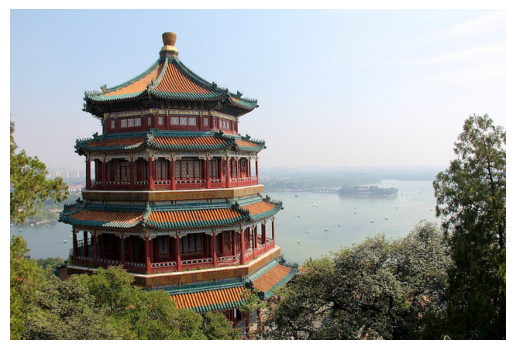

In [42]:
import matplotlib.pyplot as plt
plt.imshow(images[0])
plt.axis("off")
plt.show()

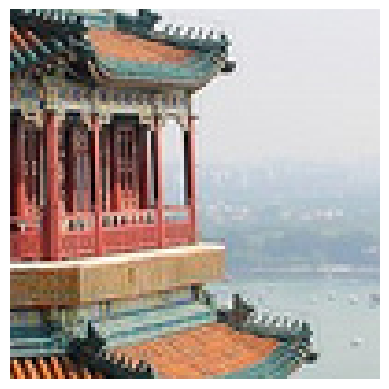

In [43]:
plt.imshow(cropped_images[0] / 255)
plt.axis("off")
plt.show()

# The TensorFlow Datasets Project

* TensorFlow Datasets (TFDS):

  * Library to **easily load standard datasets**
  * Supports:

    * Images (MNIST, ImageNet)
    * Text (translation datasets)
    * Audio, video, time series

* Key advantage:

  * No manual downloading or preprocessing
  * Ready-to-use datasets

* Loading datasets:

  * Use:

    * `tfds.load(name="dataset_name")`
  * Returns:

    * Dictionary of datasets

      * `"train"`
      * `"test"`

* Example:

  * MNIST
  * Load:

    * `datasets = tfds.load("mnist")`

* Output structure:

  * Each item:

    * Dictionary:

      * `"image"` → features
      * `"label"` → target

* Typical pipeline:

  * `shuffle()` → randomize
  * `batch()` → group samples
  * `prefetch()` → optimize performance

* Example flow:
  $$[
  \text{dataset} \rightarrow \text{shuffle} \rightarrow \text{batch} \rightarrow \text{prefetch}
  ]$$

* Important:

  * Keras expects:

    * `(features, labels)` tuples
  * TFDS provides:

    * `{features, labels}` dictionary

* Conversion:

  * Use:

    * `map(lambda x: (x["image"], x["label"]))`

* Shortcut:

  * `as_supervised=True`:

    * Directly returns:

      * `(features, labels)`

* Dataset splitting:

  * Use `split` argument:
    [
    ["train[:90%]", "train[90%:]", "test"]
    ]

* Benefit:

  * No manual splitting required

* Performance optimization:

  * `cache()`:

    * Stores dataset in memory
  * `prefetch()`:

    * Prepares next batch in advance

* Training pipeline example:

  * Load → split → preprocess → train model

* Model example:

  * Simple neural network:

    * Flatten → Dense (softmax)

* Loss function:

  * `sparse_categorical_crossentropy`

* Optimizer:

  * `nadam`

* Key takeaway:

  * TFDS simplifies:

    * **Data loading + splitting + preprocessing**
  * Works seamlessly with:

    * TensorFlow
    * Keras
  * Essential for:

    * Rapid experimentation
    * Scalable ML workflows 🚀

* Final insight:

  * Efficient data pipelines are:

    * **as important as model design**


In [4]:
import tensorflow_datasets as tfds

datasets = tfds.load(name="mnist")
mnist_train, mnist_test = datasets["train"], datasets["test"]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\roush\tensorflow_datasets\mnist\incomplete.JDE2TJ_3.0.1\mnist-train.tfrecord*...:   0%|    …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\roush\tensorflow_datasets\mnist\incomplete.JDE2TJ_3.0.1\mnist-test.tfrecord*...:   0%|     …

Dataset mnist downloaded and prepared to C:\Users\roush\tensorflow_datasets\mnist\3.0.1. Subsequent calls will reuse this data.


In [5]:
for batch in mnist_train.shuffle(10_000, seed=42).batch(32).prefetch(1):
    images = batch["image"]
    labels = batch["label"]
    # [...] do something with the images and labels

In [6]:
mnist_train = mnist_train.shuffle(10_000, seed=42).batch(32)
mnist_train = mnist_train.map(lambda items: (items["image"], items["label"]))
mnist_train = mnist_train.prefetch(1)

In [ ]:
train_set, valid_set, test_set = tfds.load(
    name="mnist",
    split=["train[:90%]", "train[90%:]", "test"],
    as_supervised=True
)
train_set = train_set.shuffle(10_000, seed=42).batch(32).prefetch(1)
valid_set = valid_set.batch(32).cache()
test_set = test_set.batch(32).cache()
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=5)
test_loss, test_accuracy = model.evaluate(test_set)

# Exersice

## 1. Why would you want to use the tf.data API?

Ingesting a large dataset and preprocessing it efficiently can be a complex engineering challenge. The Data API makes it fairly simple. It offers many features, including loading data from various sources (such as text or binary files), reading data in parallel from multiple sources, transforming it, interleaving the records, shuffling the data, batching it, and prefetching it.

## 2. What are the benefits of splitting a large dataset into multiple files?

Splitting a large dataset into multiple files makes it possible to shuffle it at a coarse level before shuffling it at a finer level using a shuffling buffer. It also makes it possible to handle huge datasets that do not fit on a single machine. It's also simpler to manipulate thousands of small files rather than one huge file; for example, it's easier to split the data into multiple subsets. Lastly, if the data is split across multiple files spread across multiple servers, it is possible to download several files from different servers simultaneously, which improves the bandwidth usage.

## 3. During training, how can you tell that your input pipeline is the bottleneck? What can you do to fix it?

You can use TensorBoard to visualize profiling data: if the GPU is not fully utilized then your input pipeline is likely to be the bottleneck. You can fix it by making sure it reads and preprocesses the data in multiple threads in parallel, and ensuring it prefetches a few batches. If this is insufficient to get your GPU to 100% usage during training, make sure your preprocessing code is optimized. You can also try saving the dataset into multiple TFRecord files, and if necessary perform some of the preprocessing ahead of time so that it does not need to be done on the fly during training (TF Transform can help with this). If necessary, use a machine with more CPU and RAM, and ensure that the GPU bandwidth is large enough.

## 4. Can you save any binary data to a TFRecord file, or only serialized protocol buffers?

A TFRecord file is composed of a sequence of arbitrary binary records: you can store absolutely any binary data you want in each record. However, in practice most TFRecord files contain sequences of serialized protocol buffers. This makes it possible to benefit from the advantages of protocol buffers, such as the fact that they can be read easily across multiple platforms and languages and their definition can be updated later in a backward-compatible way.

## 5. Why would you go through the hassle of converting all your data to the Example protobuf format? Why not use your own protobuf definition?

The `Example` protobuf format has the advantage that TensorFlow provides some operations to parse it (the `tf.io.parse`*`example()` functions) without you having to define your own format. It is sufficiently flexible to represent instances in most datasets. However, if it does not cover your use case, you can define your own protocol buffer, compile it using `protoc` (setting the `--descriptor_set_out` and `--include_imports` arguments to export the protobuf descriptor), and use the `tf.io.decode_proto()` function to parse the serialized protobufs (see the "Custom protobuf" section of the notebook for an example). It's more complicated, and it requires deploying the descriptor along with the model, but it can be done.

## 6. When using TFRecords, when would you want to activate compression? Why not do it systematically?

When using TFRecords, you will generally want to activate compression if the TFRecord files will need to be downloaded by the training script, as compression will make files smaller and thus reduce download time. But if the files are located on the same machine as the training script, it's usually preferable to leave compression off, to avoid wasting CPU for decompression.

## 7. Data can be preprocessed directly when writing the data files, or within the tf.data pipeline, or in preprocessing layers within your model. Can you list a few pros and cons of each option?

Let's look at the pros and cons of each preprocessing option:
* If you preprocess the data when creating the data files, the training script will run faster, since it will not have to perform preprocessing on the fly. In some cases, the preprocessed data will also be much smaller than the original data, so you can save some space and speed up downloads. It may also be helpful to materialize the preprocessed data, for example to inspect it or archive it. However, this approach has a few cons. First, it's not easy to experiment with various preprocessing logics if you need to generate a preprocessed dataset for each variant. Second, if you want to perform data augmentation, you have to materialize many variants of your dataset, which will use a large amount of disk space and take a lot of time to generate. Lastly, the trained model will expect preprocessed data, so you will have to add preprocessing code in your application before it calls the model. There's a risk of code duplication and preprocessing mismatch in this case.
* If the data is preprocessed with the tf.data pipeline, it's much easier to tweak the preprocessing logic and apply data augmentation. Also, tf.data makes it easy to build highly efficient preprocessing pipelines (e.g., with multithreading and prefetching). However, preprocessing the data this way will slow down training. Moreover, each training instance will be preprocessed once per epoch rather than just once if the data was preprocessed when creating the data files. Well, unless the dataset fits in RAM and you can cache it using the dataset's `cache()` method. Lastly, the trained model will still expect preprocessed data. But if you use preprocessing layers in your tf.data pipeline to handle the preprocessing step, then you can just reuse these layers in your final model (adding them after training), to avoid code duplication and preprocessing mismatch.
* If you add preprocessing layers to your model, you will only have to write the preprocessing code once for both training and inference. If your model needs to be deployed to many different platforms, you will not need to write the preprocessing code multiple times. Plus, you will not run the risk of using the wrong preprocessing logic for your model, since it will be part of the model. On the downside, preprocessing the data on the fly during training will slow things down, and each instance will be preprocessed once per epoch.

## 8. Name a few common ways you can encode categorical integer features. What about text?

Let's look at how to encode categorical text features and text:
* To encode a categorical feature that has a natural order, such as a movie rating (e.g., "bad," "average," "good"), the simplest option is to use ordinal encoding: sort the categories in their natural order and map each category to its rank (e.g., "bad" maps to 0, "average" maps to 1, and "good" maps to 2). However, most categorical features don't have such a natural order. For example, there's no natural order for professions or countries. In this case, you can use one-hot encoding, or embeddings if there are many categories. With Keras, the `StringLookup` layer can be used for ordinal encoding (using the default `output_mode="int"`), or one-hot encoding (using `output_mode="one_hot"`). It can also perform multi-hot encoding (using `output_mode="multi_hot"`) if you want to encode multiple categorical text features together, assuming they share the same categories and it doesn't matter which feature contributed which category. For trainable embeddings, you must first use the `StringLookup` layer to produce an ordinal encoding, then use the `Embedding` layer.
    * For text, the `TextVectorization` layer is easy to use and it can work well for simple tasks, or you can use TF Text for more advanced features. However, you'll often want to use pretrained language models, which you can obtain using tools like TF Hub or Hugging Face's Transformers library. These last two options are discussed in Chapter 16.

## 9. Load the Fashion MNIST dataset (introduced in Chapter 10); split it intoa training set, a validation set, and a test set; shuffle the training set; andsave each dataset to multiple TFRecord files. Each record should be aserialized Example protobuf with two features: the serialized image (use tf.io.serialize_tensor() to serialize each image), and the label.⁠ 10 Thenuse tf.data to create an efficient dataset for each set. Finally, use a Keras model to train these datasets, including a preprocessing layer to standardize each input feature. Try to make the input pipeline as efficient as possible, using TensorBoard to visualize profiling data.

In [8]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [9]:
tf.random.set_seed(42)
train_set = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_set = train_set.shuffle(len(X_train), seed=42)
valid_set = tf.data.Dataset.from_tensor_slices((X_valid, y_valid))
test_set = tf.data.Dataset.from_tensor_slices((X_test, y_test))

In [10]:
def create_example(image, label):
    image_data = tf.io.serialize_tensor(image)
    #image_data = tf.io.encode_jpeg(image[..., np.newaxis])
    return Example(
        features=Features(
            feature={
                "image": Feature(bytes_list=BytesList(value=[image_data.numpy()])),
                "label": Feature(int64_list=Int64List(value=[label])),
            }))

In [ ]:
for image, label in valid_set.take(1):
    print(create_example(image, label))

The following function saves a given dataset to a set of TFRecord files. The examples are written to the files in a round-robin fashion. To do this, we enumerate all the examples using the `dataset.enumerate()` method, and we compute `index % n_shards` to decide which file to write to. We use the standard `contextlib.ExitStack` class to make sure that all writers are properly closed whether or not an I/O error occurs while writing.

In [12]:
from contextlib import ExitStack

def write_tfrecords(name, dataset, n_shards=10):
    paths = ["{}.tfrecord-{:05d}-of-{:05d}".format(name, index, n_shards)
             for index in range(n_shards)]
    with ExitStack() as stack:
        writers = [stack.enter_context(tf.io.TFRecordWriter(path))
                   for path in paths]
        for index, (image, label) in dataset.enumerate():
            shard = index % n_shards
            example = create_example(image, label)
            writers[shard].write(example.SerializeToString())
    return paths

In [ ]:
train_filepaths = write_tfrecords("my_fashion_mnist.train", train_set)
valid_filepaths = write_tfrecords("my_fashion_mnist.valid", valid_set)
test_filepaths = write_tfrecords("my_fashion_mnist.test", test_set)

In [ ]:
def preprocess(tfrecord):
    feature_descriptions = {
        "image": tf.io.FixedLenFeature([], tf.string, default_value=""),
        "label": tf.io.FixedLenFeature([], tf.int64, default_value=-1)
    }
    example = tf.io.parse_single_example(tfrecord, feature_descriptions)
    image = tf.io.parse_tensor(example["image"], out_type=tf.uint8)
    #image = tf.io.decode_jpeg(example["image"])
    image = tf.reshape(image, shape=[28, 28])
    return image, example["label"]

def mnist_dataset(filepaths, n_read_threads=5, shuffle_buffer_size=None,
                  n_parse_threads=5, batch_size=32, cache=True):
    dataset = tf.data.TFRecordDataset(filepaths,
                                      num_parallel_reads=n_read_threads)
    if cache:
        dataset = dataset.cache()
    if shuffle_buffer_size:
        dataset = dataset.shuffle(shuffle_buffer_size)
    dataset = dataset.map(preprocess, num_parallel_calls=n_parse_threads)
    dataset = dataset.batch(batch_size)
    return dataset.prefetch(1)

In [ ]:
train_set = mnist_dataset(train_filepaths, shuffle_buffer_size=60000)
valid_set = mnist_dataset(valid_filepaths)
test_set = mnist_dataset(test_filepaths)

In [ ]:
for X, y in train_set.take(1):
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(X[i].numpy(), cmap="binary")
        plt.axis("off")
        plt.title(str(y[i].numpy()))

In [ ]:
tf.random.set_seed(42)

standardization = tf.keras.layers.Normalization(input_shape=[28, 28])

sample_image_batches = train_set.take(100).map(lambda image, label: image)
sample_images = np.concatenate(list(sample_image_batches.as_numpy_iterator()),
                               axis=0).astype(np.float32)
standardization.adapt(sample_images)

model = tf.keras.Sequential([
    standardization,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="nadam", metrics=["accuracy"])

In [ ]:
from datetime import datetime

logs = Path() / "my_logs" / "run_" / datetime.now().strftime("%Y%m%d_%H%M%S")

tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir=logs, histogram_freq=1, profile_batch=10)

model.fit(train_set, epochs=5, validation_data=valid_set,
          callbacks=[tensorboard_cb])

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs

## 10. In this exercise you will download a dataset, split it, create a tf.data.Dataset to load it and preprocess it efficiently, then build and train a binary classification model containing an Embedding layer:
1. Download the Large Movie Review Dataset, which contains 50,000
movie reviews from the Internet Movie Database (IMDb). The data
is organized in two directories, train and test, each containing a pos
subdirectory with 12,500 positive reviews and a neg subdirectory
with 12,500 negative reviews. Each review is stored in a separate
text file. There are other files and folders (including preprocessed
bag-of-words versions), but we will ignore them in this exercise.
2. Split the test set into a validation set (15,000) and a test set
(10,000).
3. Use tf.data to create an efficient dataset for each set.
4. Create a binary classification model, using a TextVectorization
layer to preprocess each review.
5. Add an Embedding layer and compute the mean embedding for
each review, multiplied by the square root of the number of words
(see Chapter 16). This rescaled mean embedding can then be
passed to the rest of your model.
6. Train the model and see what accuracy you get. Try to optimize
your pipelines to make training as fast as possible.
7. Use TFDS to load the same dataset more easily:
tfds.load("imdb_reviews").

In [ ]:
from pathlib import Path

root = "https://ai.stanford.edu/~amaas/data/sentiment/"
filename = "aclImdb_v1.tar.gz"
filepath = tf.keras.utils.get_file(filename, root + filename, extract=True,
                                   cache_dir=".")
if "_extracted" in filepath:
    path = Path(filepath) / "aclImdb"
else:
    path = Path(filepath).with_name("aclImdb")

In [ ]:
def tree(path, level=0, indent=4, max_files=3):
    if level == 0:
        print(f"{path}/")
        level += 1
    sub_paths = sorted(path.iterdir())
    sub_dirs = [sub_path for sub_path in sub_paths if sub_path.is_dir()]
    filepaths = [sub_path for sub_path in sub_paths if not sub_path in sub_dirs]
    indent_str = " " * indent * level
    for sub_dir in sub_dirs:
        print(f"{indent_str}{sub_dir.name}/")
        tree(sub_dir,  level + 1, indent)
    for filepath in filepaths[:max_files]:
        print(f"{indent_str}{filepath.name}")
    if len(filepaths) > max_files:
        print(f"{indent_str}...")

In [ ]:
tree(path)

In [ ]:
def review_paths(dirpath):
    return [str(path) for path in dirpath.glob("*.txt")]

train_pos = review_paths(path / "train" / "pos")
train_neg = review_paths(path / "train" / "neg")
test_valid_pos = review_paths(path / "test" / "pos")
test_valid_neg = review_paths(path / "test" / "neg")

len(train_pos), len(train_neg), len(test_valid_pos), len(test_valid_neg)

In [ ]:
np.random.shuffle(test_valid_pos)

test_pos = test_valid_pos[:5000]
test_neg = test_valid_neg[:5000]
valid_pos = test_valid_pos[5000:]
valid_neg = test_valid_neg[5000:]

In [ ]:
def imdb_dataset(filepaths_positive, filepaths_negative):
    reviews = []
    labels = []
    for filepaths, label in ((filepaths_negative, 0), (filepaths_positive, 1)):
        for filepath in filepaths:
            with open(filepath) as review_file:
                reviews.append(review_file.read())
            labels.append(label)
    return tf.data.Dataset.from_tensor_slices(
        (tf.constant(reviews), tf.constant(labels)))

In [ ]:
for X, y in imdb_dataset(train_pos, train_neg).take(3):
    print(X)
    print(y)
    print()

In [ ]:
%timeit -r1 for X, y in imdb_dataset(train_pos, train_neg).repeat(10): pass

But let's pretend the dataset does not fit in memory, just to make things more interesting. Luckily, each review fits on just one line (they use `<br />` to indicate line breaks), so we can read the reviews using a `TextLineDataset`. If they didn't we would have to preprocess the input files (e.g., converting them to TFRecords). For very large datasets, it would make sense to use a tool like Apache Beam for that.

In [ ]:
def imdb_dataset(filepaths_positive, filepaths_negative, n_read_threads=5):
    dataset_neg = tf.data.TextLineDataset(filepaths_negative,
                                          num_parallel_reads=n_read_threads)
    dataset_neg = dataset_neg.map(lambda review: (review, 0))
    dataset_pos = tf.data.TextLineDataset(filepaths_positive,
                                          num_parallel_reads=n_read_threads)
    dataset_pos = dataset_pos.map(lambda review: (review, 1))
    return tf.data.Dataset.concatenate(dataset_pos, dataset_neg)

In [ ]:
%timeit -r1 for X, y in imdb_dataset(train_pos, train_neg).repeat(10): pass

Now it takes about 33 seconds to go through the dataset 10 times. That's much slower, essentially because the dataset is not cached in RAM, so it must be reloaded at each epoch. If you add `.cache()` just before `.repeat(10)`, you will see that this implementation will be about as fast as the previous one.

In [ ]:
%timeit -r1 for X, y in imdb_dataset(train_pos, train_neg).cache().repeat(10): pass

In [ ]:
batch_size = 32

train_set = imdb_dataset(train_pos, train_neg).shuffle(25000, seed=42)
train_set = train_set.batch(batch_size).prefetch(1)
valid_set = imdb_dataset(valid_pos, valid_neg).batch(batch_size).prefetch(1)
test_set = imdb_dataset(test_pos, test_neg).batch(batch_size).prefetch(1)

In [ ]:
max_tokens = 1000
sample_reviews = train_set.map(lambda review, label: review)
text_vectorization = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens, output_mode="tf_idf")
text_vectorization.adapt(sample_reviews)

In [ ]:
text_vectorization.get_vocabulary()[:10]

In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    text_vectorization,
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit(train_set, epochs=5, validation_data=valid_set)

To compute the mean embedding for each review, and multiply it by the square root of the number of words in that review, we will need a little function. For each sentence, this function needs to compute $M \times \sqrt N$, where $M$ is the mean of all the word embeddings in the sentence (excluding padding tokens), and $N$ is the number of words in the sentence (also excluding padding tokens). We can rewrite $M$ as $\dfrac{S}{N}$, where $S$ is the sum of all word embeddings (it does not matter whether or not we include the padding tokens in this sum, since their representation is a zero vector). So the function must return $M \times \sqrt N = \dfrac{S}{N} \times \sqrt N = \dfrac{S}{\sqrt N \times \sqrt N} \times \sqrt N= \dfrac{S}{\sqrt N}$.

In [ ]:
def compute_mean_embedding(inputs):
    not_pad = tf.math.count_nonzero(inputs, axis=-1)
    n_words = tf.math.count_nonzero(not_pad, axis=-1, keepdims=True)    
    sqrt_n_words = tf.math.sqrt(tf.cast(n_words, tf.float32))
    return tf.reduce_sum(inputs, axis=1) / sqrt_n_words

another_example = tf.constant([[[1., 2., 3.], [4., 5., 0.], [0., 0., 0.]],
                               [[6., 0., 0.], [0., 0., 0.], [0., 0., 0.]]])
compute_mean_embedding(another_example)

In [ ]:
tf.reduce_mean(another_example[0:1, :2], axis=1) * tf.sqrt(2.)

In [ ]:
tf.reduce_mean(another_example[1:2, :1], axis=1) * tf.sqrt(1.)

In [ ]:
embedding_size = 20
tf.random.set_seed(42)

text_vectorization = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens, output_mode="int")
text_vectorization.adapt(sample_reviews)

model = tf.keras.Sequential([
    text_vectorization,
    tf.keras.layers.Embedding(input_dim=max_tokens,
                              output_dim=embedding_size,
                              mask_zero=True),  # <pad> tokens => zero vectors
    tf.keras.layers.Lambda(compute_mean_embedding),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

In [ ]:
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.fit(train_set, epochs=5, validation_data=valid_set)

In [ ]:
import tensorflow_datasets as tfds

datasets = tfds.load(name="imdb_reviews")
train_set, test_set = datasets["train"], datasets["test"]

In [ ]:
for example in train_set.take(1):
    print(example["text"])
    print(example["label"])

-------- End ------------